# E-commerce Marketing and sales

## --> Know the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler


online_sales_data = pd.read_csv(r"C:\Users\Srivathsan V\Desktop\scaler\01)project_dav\Online_Sales.csv")
customers_data = pd.read_excel(r"C:\Users\Srivathsan V\Desktop\scaler\01)project_dav\CustomersData.xlsx")
discount_coupan_data = pd.read_csv(r"C:\Users\Srivathsan V\Desktop\scaler\01)project_dav\Discount_Coupon.csv")
marketing_spend_data = pd.read_csv(r"C:\Users\Srivathsan V\Desktop\scaler\01)project_dav\Marketing_Spend.csv")
tax_amount_data = pd.read_excel(r"C:\Users\Srivathsan V\Desktop\scaler\01)project_dav\Tax_amount.xlsx")

In [2]:
print("First 5 rows:\n===================================================")
print(online_sales_data.head(5))

print("\nData Info:\n===================================================")
online_sales_data.info()

print("\nShape of the DataFrame:\n===================================================")
print(online_sales_data.shape)

print("\nMissing Values per Column:\n===================================================")
print(online_sales_data.isna().sum())

# Note : You cannot use .sum() instead as .count() as that will add up all the transaction ID values
print("\n How many transactions each cutomer made ?:\n===================================================")
transaction_made_per_cutomer = online_sales_data.groupby('CustomerID')['Transaction_ID'].count()
print(transaction_made_per_cutomer)

print("\n Average transactions per person ?:\n===================================================")
avg_transaction_made_per_cutomer = online_sales_data.groupby('CustomerID')['Transaction_ID'].count().mean()
print(avg_transaction_made_per_cutomer)

#Converting the type of 'Transaction_Date' column to 'datetime' and fetching the months seperately 
# and storing it in a new column
online_sales_data['Transaction_Date'] = pd.to_datetime(online_sales_data['Transaction_Date'])
online_sales_data['Month'] = online_sales_data['Transaction_Date'].dt.month

print("\n Number of transactions on each month:\n===================================================")
transaction_made_per_month = online_sales_data.groupby('Month')['Transaction_ID'].count()
print(transaction_made_per_month)

print("\nAverage Number of transactions on each month:\n===================================================")
transaction_made_per_month = online_sales_data.groupby('Month')['Transaction_ID'].count().mean()
print(transaction_made_per_month)
      
print("\nList of unique products:\n===================================================")
unique_products = online_sales_data['Product_SKU'].unique()
print(unique_products)

print("\nCount of unique product IDS:\n===================================================")
unique_products_count = online_sales_data['Product_SKU'].nunique()
print(unique_products_count)

print("\nList of unique product categories:\n===================================================")
unique_product_categories = online_sales_data['Product_Category'].unique()
print(unique_product_categories)

print("\nCount of unique product categories:\n===================================================")
unique_product_category_counts = online_sales_data['Product_Category'].nunique()
print(unique_products_count)

print("\nHow many products in each category:\n===================================================")
products_per_category = online_sales_data.groupby('Product_Category')['Product_SKU'].count()
print(products_per_category)

print("\nAverage of avg_price per month :\n===================================================")
avg_price_per_month =  online_sales_data.groupby('Month')['Avg_Price'].mean()
print(avg_price_per_month)


First 5 rows:
   CustomerID  Transaction_ID Transaction_Date     Product_SKU  \
0       17850           16679         1/1/2019  GGOENEBJ079499   
1       17850           16680         1/1/2019  GGOENEBJ079499   
2       17850           16681         1/1/2019  GGOEGFKQ020399   
3       17850           16682         1/1/2019  GGOEGAAB010516   
4       17850           16682         1/1/2019  GGOEGBJL013999   

                                 Product_Description Product_Category  \
0  Nest Learning Thermostat 3rd Gen-USA - Stainle...         Nest-USA   
1  Nest Learning Thermostat 3rd Gen-USA - Stainle...         Nest-USA   
2              Google Laptop and Cell Phone Stickers           Office   
3  Google Men's 100% Cotton Short Sleeve Hero Tee...          Apparel   
4                    Google Canvas Tote Natural/Navy             Bags   

   Quantity  Avg_Price  Delivery_Charges Coupon_Status  
0         1     153.71               6.5          Used  
1         1     153.71              

In [3]:
print("First 5 rows:\n===================================================")
print(customers_data.head(5))

print("\nData Info:\n===================================================")
customers_data.info()

print("\nShape of the DataFrame:\n===================================================")
print(customers_data.shape)

print("\nMissing Values per Column:\n===================================================")
print(customers_data.isna().sum())

# print("\nNon-null Counts per Column:\n===================================================")
# print(customers_data.count())

# Do not use count() ->  as the condition will return a series and count() will return no. of not null entries from that series
print("\nHow many are customers are Male ?:\n===================================================")
print((customers_data["Gender"] == "M").sum()) 

print("\nHow many are customers are Female ?:\n===================================================")
print((customers_data["Gender"] == "F").sum()) 

# Note : Unique returns a numpy array and not a series
print("\nHow many unique locations are there ?:\n===================================================")
print(customers_data["Location"].unique()) 

print("\nWhat is the average tenure duration in months ?:\n===================================================")
print(customers_data["Tenure_Months"].mean()) 

print("\nWhat is the average tenure duration in months (MALE) ?:\n===================================================")
print(customers_data[customers_data["Gender"] == "M"]['Tenure_Months'].mean())

print("\nWhat is the average tenure duration in months (FEMALEL) ?:\n===================================================")
print(customers_data[customers_data["Gender"] == "F"]['Tenure_Months'].mean())

# Note : We can use groupby to get the mean value of multiple groups 
print("\nWhat is the average tenure duration in months (MALEL/FEMALE) ?:\n===================================================")
print(customers_data.groupby('Gender')['Tenure_Months'].mean())

print("\nWhat is the average tenure duration in each location?:\n===================================================")
avg_tenure_by_location = customers_data.groupby('Location')['Tenure_Months'].mean()
print(avg_tenure_by_location)

# Note : We can use groupby with list of columns to get the mean value of multiple sub-groups of different groups
print("\nWhat is the average tenure duration in each location with respect to gender ?:\n===================================================")
avg_tenure_by_location_gender = customers_data.groupby(['Location','Gender'])['Tenure_Months'].mean()
print(avg_tenure_by_location_gender)



First 5 rows:
   CustomerID Gender    Location  Tenure_Months
0       17850      M     Chicago             12
1       13047      M  California             43
2       12583      M     Chicago             33
3       13748      F  California             30
4       15100      M  California             49

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB

Shape of the DataFrame:
(1468, 4)

Missing Values per Column:
CustomerID       0
Gender           0
Location         0
Tenure_Months    0
dtype: int64

How many are customers are Male ?:
534

How many are customers are Female ?:
934

How many unique locations are there 

In [4]:
print("First 5 rows:\n===================================================")
print(discount_coupan_data.head(5))

print("\nData Info:\n===================================================")
discount_coupan_data.info()

print("\nShape of the DataFrame:\n===================================================")
print(discount_coupan_data.shape)

print("\nMissing Values per Column:\n===================================================")
print(discount_coupan_data.isna().sum())

print("\nNon-null Counts per Column:\n===================================================")
print(discount_coupan_data.count())

print("\nFor each month how many coupans are available ?:\n===================================================")
coupans_available_per_month = discount_coupan_data.groupby('Month')['Coupon_Code'].count()
print(coupans_available_per_month)

print("\nAverage discount available for each month ?:\n===================================================")
avg_disc_per_month = discount_coupan_data.groupby('Month')['Discount_pct'].mean()
print(avg_disc_per_month)

#This is to have consistency in 'Month' colummn accross all dataset 
# Mapping of month names to numbers
month_map = {
    'Jan': 1, 'January': 1,
    'Feb': 2, 'February': 2,
    'Mar': 3, 'March': 3,
    'Apr': 4, 'April': 4,
    'May': 5,
    'Jun': 6, 'June': 6,
    'Jul': 7, 'July': 7,
    'Aug': 8, 'August': 8,
    'Sep': 9, 'Sept': 9, 'September': 9,
    'Oct': 10, 'October': 10,
    'Nov': 11, 'November': 11,
    'Dec': 12, 'December': 12
}

# Apply mapping to the 'Month' column in your datasets
discount_coupan_data['Month'] = discount_coupan_data['Month'].map(month_map)





First 5 rows:
  Month Product_Category Coupon_Code  Discount_pct
0   Jan          Apparel      SALE10            10
1   Feb          Apparel      SALE20            20
2   Mar          Apparel      SALE30            30
3   Jan         Nest-USA      ELEC10            10
4   Feb         Nest-USA      ELEC20            20

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             204 non-null    object
 1   Product_Category  204 non-null    object
 2   Coupon_Code       204 non-null    object
 3   Discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB

Shape of the DataFrame:
(204, 4)

Missing Values per Column:
Month               0
Product_Category    0
Coupon_Code         0
Discount_pct        0
dtype: int64

Non-null Counts per Column:
Month               204
Product_Category    20

In [5]:
print("First 5 rows:\n===================================================")
print(marketing_spend_data.head(5))

print("\nData Info:\n===================================================")
marketing_spend_data.info()

print("\nShape of the DataFrame:\n===================================================")
print(marketing_spend_data.shape)

print("\nMissing Values per Column:\n===================================================")
print(marketing_spend_data.isna().sum())

print("\nAverage offline spend:\n===================================================")
print(marketing_spend_data['Offline_Spend'].mean())

print("\nAverage online spend:\n===================================================")
print(marketing_spend_data['Online_Spend'].mean())

#Converting the type of 'Transaction_Date' column to 'datetime' and fetching the months seperately 
# and storing it in a new column
marketing_spend_data['Date'] = pd.to_datetime(marketing_spend_data['Date'])
marketing_spend_data['Month'] = marketing_spend_data['Date'].dt.month

print("\nAverage offline spend per month:\n===================================================")
avg_offline_spend_per_month = marketing_spend_data.groupby('Month')['Offline_Spend'].mean()
print(avg_offline_spend_per_month)

print("\nAverage online spend per month:\n===================================================")
avg_online_spend_per_month = marketing_spend_data.groupby('Month')['Online_Spend'].mean()
print(avg_online_spend_per_month)

First 5 rows:
       Date  Offline_Spend  Online_Spend
0  1/1/2019           4500       2424.50
1  1/2/2019           4500       3480.36
2  1/3/2019           4500       1576.38
3  1/4/2019           4500       2928.55
4  1/5/2019           4500       4055.30

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Offline_Spend  365 non-null    int64  
 2   Online_Spend   365 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.7+ KB

Shape of the DataFrame:
(365, 3)

Missing Values per Column:
Date             0
Offline_Spend    0
Online_Spend     0
dtype: int64

Average offline spend:
2843.5616438356165

Average online spend:
1905.8807397260264

Average offline spend per month:
Month
1     3116.129032
2     2903.571429
3     2370.967742
4     3200.000000
5     2112.90

In [6]:
print("First 5 rows:\n===================================================")
print(tax_amount_data.head(5))

print("\nData Info:\n===================================================")
tax_amount_data.info()

print("\nShape of the DataFrame:\n===================================================")
print(tax_amount_data.shape)

print("\nMissing Values per Column:\n===================================================")
print(tax_amount_data.isna().sum())

print("\nAverage GST % across all product categories:\n===================================================")
print(tax_amount_data['GST'].mean())


First 5 rows:
  Product_Category   GST
0         Nest-USA  0.10
1           Office  0.10
2          Apparel  0.18
3             Bags  0.18
4        Drinkware  0.18

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_Category  20 non-null     object 
 1   GST               20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 448.0+ bytes

Shape of the DataFrame:
(20, 2)

Missing Values per Column:
Product_Category    0
GST                 0
dtype: int64

Average GST % across all product categories:
0.1165


## --> Merge all the datasets for overal visualization of existing data

In [7]:
merged_data = pd.merge(
    online_sales_data,
    customers_data,
    on='CustomerID',
    how='left'  # Keep all transactions even if customer data is missing
)
merged_data = pd.merge(
    merged_data,
    discount_coupan_data,
    left_on=['Product_Category', 'Month'],
    right_on=['Product_Category', 'Month'],
    how='left'  # Keep transactions even if no coupon existed
)
merged_data = pd.merge(
    merged_data,
    marketing_spend_data,
    left_on='Transaction_Date',
    right_on='Date',
    how='left'  # Keep transactions even if marketing data is missing
)
merged_data = pd.merge(
    merged_data,
    tax_amount_data,
    left_on='Product_Category',
    right_on='Product_Category',
    how='left'  # Keep transactions even if tax data is missing
)

print("\nmerged_data.info() :\n")
print(merged_data.info())

merged_data['Revenue'] = merged_data['Quantity'] * merged_data['Avg_Price']
merged_data['Total_Revenue'] = merged_data['Revenue'] + merged_data['Delivery_Charges']
merged_data['Total_Revenue_After_Discount'] = merged_data['Total_Revenue'] * (1 - merged_data['Discount_pct'].fillna(0)/100)
merged_data['Is_Weekend'] = merged_data['Transaction_Date'].dt.dayofweek >= 5
merged_data['YearMonth'] = merged_data['Transaction_Date'].dt.to_period('M')
merged_data['DayOfWeek'] = merged_data['Transaction_Date'].dt.day_name()
merged_data['Day'] = merged_data['Transaction_Date'].dt.day


merged_data.drop(columns=['Month_x'], inplace=True)
merged_data.rename(columns={'Month_y': 'Month'}, inplace=True)
merged_data


merged_data.info() :

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52924 entries, 0 to 52923
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  int64         
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  Month_x              52924 non-null  int64         
 11  Gender               52924 non-null  object        
 12  Location             52924 non-null  object        
 13  Tenure_M

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,...,Online_Spend,Month,GST,Revenue,Total_Revenue,Total_Revenue_After_Discount,Is_Weekend,YearMonth,DayOfWeek,Day
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,2424.50,1,0.10,153.71,160.21,144.189,False,2019-01,Tuesday,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,...,2424.50,1,0.10,153.71,160.21,144.189,False,2019-01,Tuesday,1
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,...,2424.50,1,0.10,2.05,8.55,7.695,False,2019-01,Tuesday,1
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,...,2424.50,1,0.18,87.65,94.15,84.735,False,2019-01,Tuesday,1
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,...,2424.50,1,0.18,16.50,23.00,20.700,False,2019-01,Tuesday,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,...,2058.75,12,0.10,121.30,127.80,89.460,False,2019-12,Tuesday,31
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,...,2058.75,12,0.18,48.92,55.42,38.794,False,2019-12,Tuesday,31
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,...,2058.75,12,0.10,151.88,158.38,110.866,False,2019-12,Tuesday,31
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,...,2058.75,12,0.10,402.60,409.10,286.370,False,2019-12,Tuesday,31


## --> Business questions:

### 01) Identify the months with the highest and lowest acquisition rates. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year?

first_purchases:       CustomerID Transaction_Date
0          12346       2019-09-15
1          12347       2019-03-24
2          12348       2019-06-22
3          12350       2019-12-14
4          12356       2019-09-15
...          ...              ...
1463       18259       2019-04-05
1464       18260       2019-06-22
1465       18269       2019-04-05
1466       18277       2019-10-23
1467       18283       2019-07-29

[1468 rows x 2 columns]


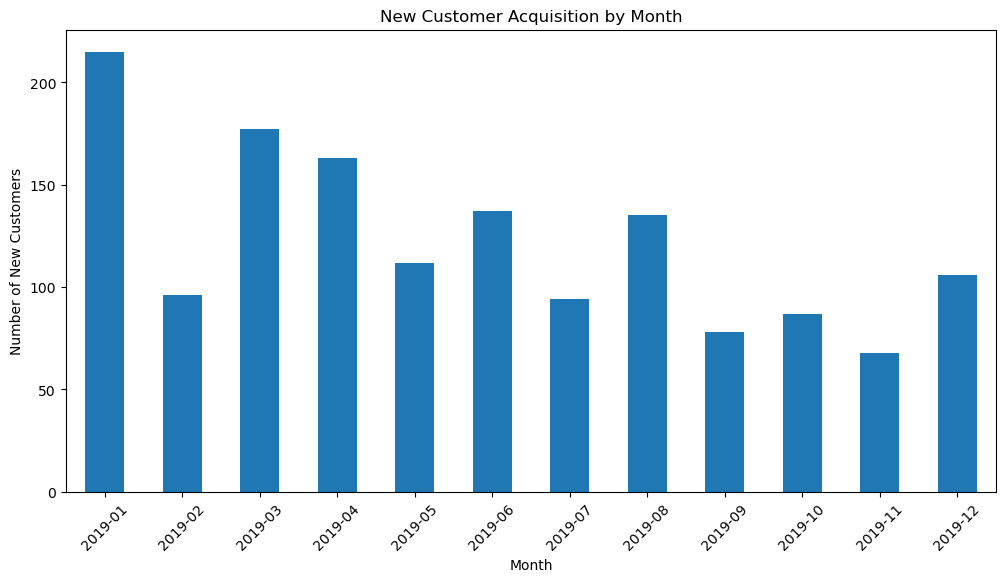


Highest acquisition month: 2019-01 with 215 new customers
Lowest acquisition month: 2019-11 with 68 new customers

Strategies to address fluctuations:
1. For high acquisition months: Capitalize on what's working - analyze marketing spend, promotions, and external factors
2. For low acquisition months: Increase targeted marketing, offer seasonal promotions, or bundle products
3. Implement retention programs to maintain customer base during slower months
4. Consider running 'off-season' promotions to smooth out demand
5. Analyze competitor activity during low months - are they capturing market share?


In [8]:
# Calculate new customer acquisition by month
first_purchases = merged_data.groupby('CustomerID')['Transaction_Date'].min().reset_index()
print("first_purchases:",first_purchases)
first_purchases['YearMonth'] = first_purchases['Transaction_Date'].dt.to_period('M')
acquisition_by_month = first_purchases['YearMonth'].value_counts().sort_index()

# Plot acquisition by month
plt.figure(figsize=(12, 6))
acquisition_by_month.plot(kind='bar')
plt.title('New Customer Acquisition by Month')
plt.xlabel('Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=45)
plt.show()

# Identify highest and lowest months
max_month = acquisition_by_month.idxmax()
min_month = acquisition_by_month.idxmin()

print(f"\nHighest acquisition month: {max_month} with {acquisition_by_month[max_month]} new customers")
print(f"Lowest acquisition month: {min_month} with {acquisition_by_month[min_month]} new customers")

# Strategies
print("\nStrategies to address fluctuations:")
print("1. For high acquisition months: Capitalize on what's working - analyze marketing spend, promotions, and external factors")
print("2. For low acquisition months: Increase targeted marketing, offer seasonal promotions, or bundle products")
print("3. Implement retention programs to maintain customer base during slower months")
print("4. Consider running 'off-season' promotions to smooth out demand")
print("5. Analyze competitor activity during low months - are they capturing market share?")

### 02) Analyze the data to determine if certain months consistently show higher or lower acquisition rates. How can the company capitalize on high-performing months and improve performance during slower periods?


<Figure size 1200x1000 with 0 Axes>

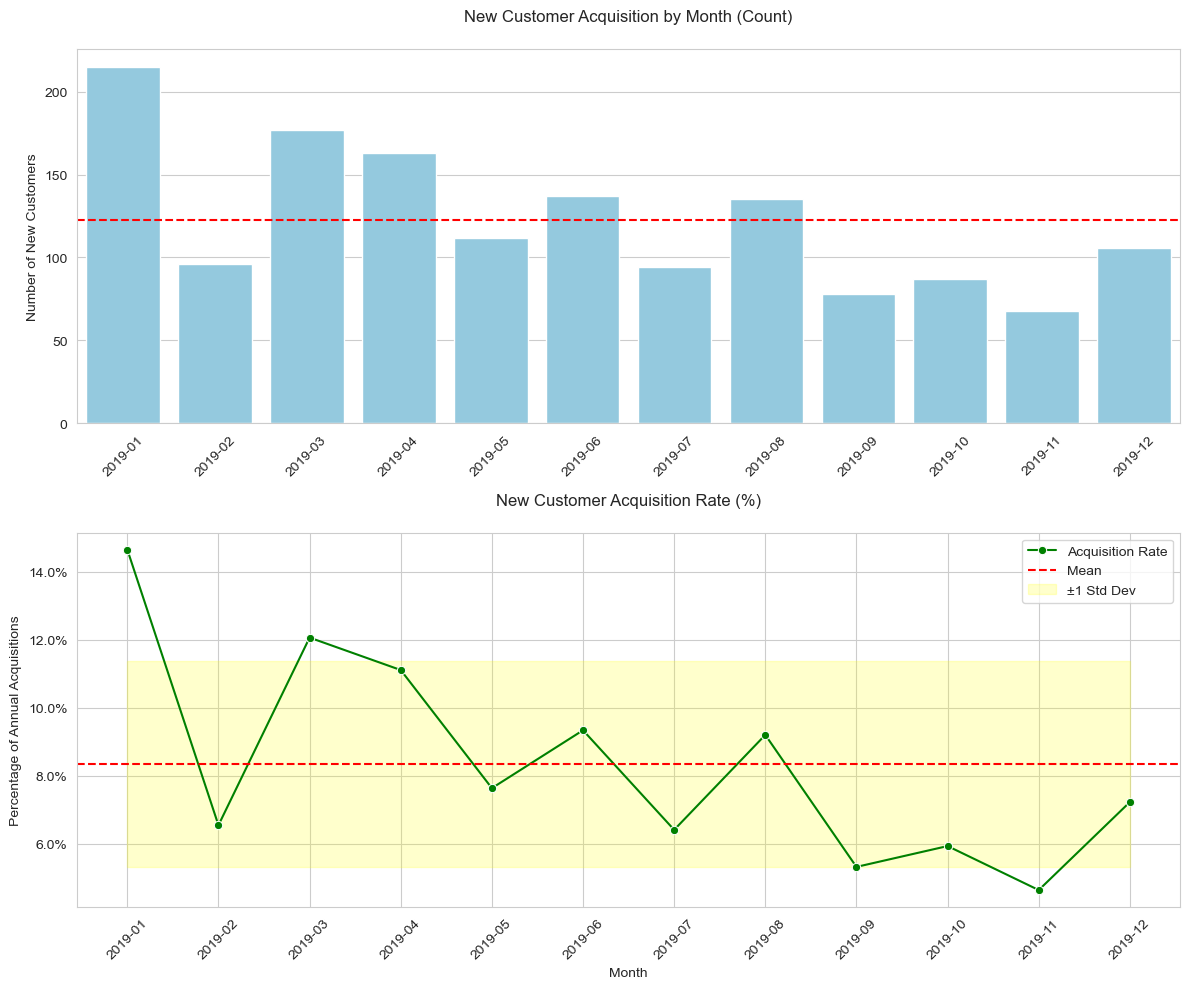


Acquisition Rate Analysis:
Mean monthly acquisition: 122.3 customers
Highest month: 2019-01 (215 customers, 2.09σ)
Lowest month: 2019-11 (68 customers, -1.22σ)

Strategic Recommendations:
1. For High-Performing Months:
   - Double down on successful acquisition channels
   - Analyze seasonal factors (holidays, weather, etc.)
   - Consider increasing inventory/staffing to handle demand

2. For Low-Performing Months:
   - Run targeted promotions for customer segments with untapped potential
   - Test referral programs or partnerships
   - Allocate marketing budget from peak months to build year-round demand

Important Caveat:
With only one year of data, we cannot confirm true seasonality patterns.
Recommend collecting additional year(s) of data to verify these trends.


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

acquisition_rate = (acquisition_by_month / acquisition_by_month.sum()) * 100
z_scores = (acquisition_by_month - acquisition_by_month.mean()) / acquisition_by_month.std()

# Set Seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

# 1. Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 2. Acquisition Volume (Bar plot)
sns.barplot(x=acquisition_by_month.index.astype(str), 
            y=acquisition_by_month.values, 
            color='skyblue', 
            ax=ax1)
ax1.axhline(acquisition_by_month.mean(), color='red', linestyle='--')
ax1.set_title('New Customer Acquisition by Month (Count)', pad=20)
ax1.set_ylabel('Number of New Customers')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

# 3. Acquisition Rate (Line plot with CI bands)
months = acquisition_by_month.index.astype(str)
sns.lineplot(x=months, 
             y=acquisition_rate.values, 
             marker='o', 
             color='green', 
             ax=ax2, 
             label='Acquisition Rate')
ax2.axhline(acquisition_rate.mean(), color='red', linestyle='--', label='Mean')
ax2.fill_between(months,
                (acquisition_rate.mean() - acquisition_rate.std()),
                (acquisition_rate.mean() + acquisition_rate.std()),
                color='yellow', alpha=0.2, label='±1 Std Dev')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_title('New Customer Acquisition Rate (%)', pad=20)
ax2.set_ylabel('Percentage of Annual Acquisitions')
ax2.set_xlabel('Month')
ax2.legend(loc='upper right')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. Statistical analysis (text output remains identical)
print("\nAcquisition Rate Analysis:")
print(f"Mean monthly acquisition: {acquisition_by_month.mean():.1f} customers")
print(f"Highest month: {acquisition_by_month.idxmax()} ({acquisition_by_month.max()} customers, {z_scores.max():.2f}σ)")
print(f"Lowest month: {acquisition_by_month.idxmin()} ({acquisition_by_month.min()} customers, {z_scores.min():.2f}σ)")

# 5. Strategic recommendations (identical text output)
print("\nStrategic Recommendations:")
print("1. For High-Performing Months:")
print("   - Double down on successful acquisition channels")
print("   - Analyze seasonal factors (holidays, weather, etc.)")
print("   - Consider increasing inventory/staffing to handle demand")

print("\n2. For Low-Performing Months:")
print("   - Run targeted promotions for customer segments with untapped potential")
print("   - Test referral programs or partnerships")
print("   - Allocate marketing budget from peak months to build year-round demand")

print("\nImportant Caveat:")
print("With only one year of data, we cannot confirm true seasonality patterns.")
print("Recommend collecting additional year(s) of data to verify these trends.")

### 03) Identify periods with the strongest and weakest retention rates. What strategies could be implemented to improve retention during weaker months?



retention_matrix CohortPeriod                          0         1         2         3   \
first_transaction_month_of_customer                                      
2019-01                              1.0  0.060465  0.111628  0.158140   
2019-02                              1.0  0.072917  0.093750  0.166667   
2019-03                              1.0  0.101695  0.197740  0.141243   
2019-04                              1.0  0.085890  0.147239  0.147239   
2019-05                              1.0  0.107143  0.080357  0.116071   
2019-06                              1.0  0.145985  0.160584  0.087591   
2019-07                              1.0  0.138298  0.042553  0.063830   
2019-08                              1.0  0.103704  0.111111  0.074074   
2019-09                              1.0  0.076923  0.038462  0.025641   
2019-10                              1.0  0.068966  0.045977       NaN   
2019-11                              1.0  0.102941       NaN       NaN   
2019-12              

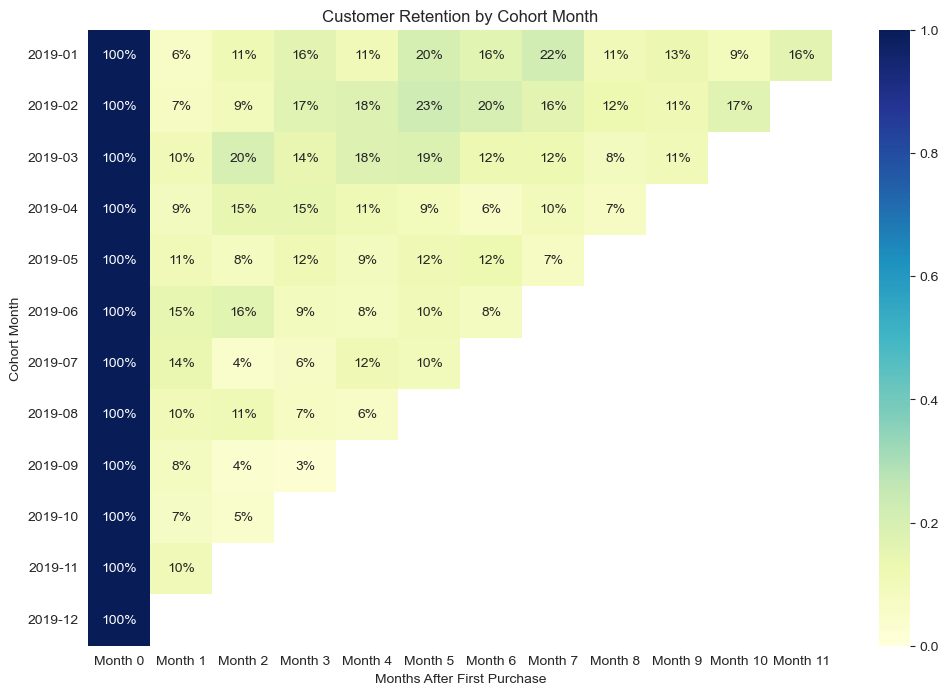


Best performing cohort: 2019-12 with 100.0% average retention
Worst performing cohort: 2019-04 with 20.2% average retention

Strategies to improve retention:
1. Identify the drop-off points in customer lifecycle and implement targeted interventions
2. For weak retention months: Implement win-back campaigns with personalized offers
3. Enhance customer service during critical post-purchase periods
4. Develop automated engagement sequences for customers at risk of churning
5. Analyze common characteristics of retained vs. churned customers to identify patterns
6. Focus on improving the onboarding experience for new customers in weak cohorts
7. Implement loyalty programs that reward repeat purchases
8. Analyze purchase patterns of retained customers and encourage similar behavior in at-risk customers


In [10]:
# Calculate retention by cohort (month of first purchase)
cohorts = first_purchases[['CustomerID','YearMonth']]
cohorts.columns = ['CustomerID', 'first_transaction_month_of_customer']
# print("cohorts",cohorts)
# print("first_purchases",first_purchases)

# Merge cohort information back to the original data
merged_data_cohort = merged_data.merge(cohorts, on='CustomerID')
# print("merged_data_cohort",merged_data_cohort)

# Create period (month) for each transaction
merged_data_cohort['TransactionPeriod'] = merged_data_cohort['Transaction_Date'].dt.to_period('M')

# Calculate cohort periods (months since first purchase)
merged_data_cohort['CohortPeriod'] = (merged_data_cohort['TransactionPeriod'] - merged_data_cohort['first_transaction_month_of_customer']).apply(lambda x: x.n)

# Calculate unique customers per cohort-period
cohort_data = merged_data_cohort.groupby(['first_transaction_month_of_customer', 'CohortPeriod'])['CustomerID'].nunique().reset_index()
# print("cohort_data",cohort_data)
cohort_data.columns = ['first_transaction_month_of_customer','CohortPeriod','CustomerID_count_per_cohort']
cohort_counts = cohort_data.pivot_table(index='first_transaction_month_of_customer', columns='CohortPeriod', values='CustomerID_count_per_cohort')
# print("cohort_counts",cohort_counts)
# Calculate retention rates
cohort_sizes = cohort_counts.iloc[:, 0]
# print("cohort_sizes",cohort_sizes)
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)
print("retention_matrix",retention_matrix)
# print("type(retention_matrix)",type(retention_matrix))
# Format for display
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')
retention_matrix.columns = ['Month ' + str(col) for col in retention_matrix.columns]

# Plot retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.0%', 
            cmap='YlGnBu',
            vmin=0.0,
            vmax=1.0)
plt.title('Customer Retention by Cohort Month')
plt.ylabel('Cohort Month')
plt.xlabel('Months After First Purchase')
plt.yticks(rotation=0)
plt.show()

# Identify best and worst cohorts
avg_retention = retention_matrix.mean(axis=1)
best_cohort = avg_retention.idxmax()
worst_cohort = avg_retention.idxmin()

print(f"\nBest performing cohort: {best_cohort} with {avg_retention.max():.1%} average retention")
print(f"Worst performing cohort: {worst_cohort} with {avg_retention.min():.1%} average retention")

# Strategies
print("\nStrategies to improve retention:")
print("1. Identify the drop-off points in customer lifecycle and implement targeted interventions")
print("2. For weak retention months: Implement win-back campaigns with personalized offers")
print("3. Enhance customer service during critical post-purchase periods")
print("4. Develop automated engagement sequences for customers at risk of churning")
print("5. Analyze common characteristics of retained vs. churned customers to identify patterns")
print("6. Focus on improving the onboarding experience for new customers in weak cohorts")
print("7. Implement loyalty programs that reward repeat purchases")
print("8. Analyze purchase patterns of retained customers and encourage similar behavior in at-risk customers")

### 04) Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.

<Figure size 1400x800 with 0 Axes>

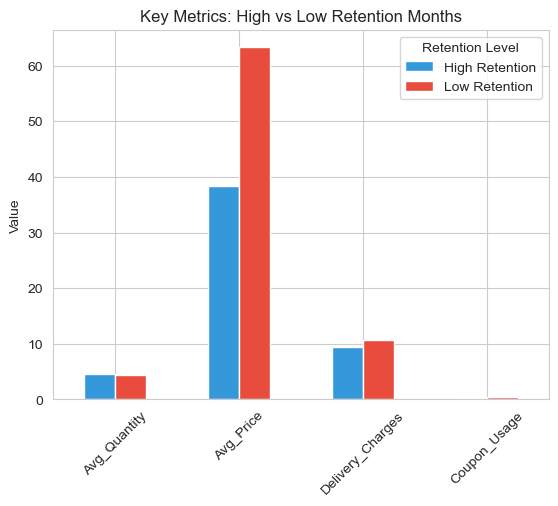


High Retention Months: ['2019-08', '2019-06', '2019-07']
Low Retention Months: ['2019-02', '2019-11', '2019-09']

Key Differences:
1. Average Quantity: 4.6 vs 4.4
2. Average Price: $38.41 vs $63.28
3. Delivery Charges: $9.45 vs $10.62
4. Coupon Usage: 33.8% vs 34.3%

Top Categories in High-Retention Months:
- Apparel: 42.6%
- Nest-USA: 21.3%
- Office: 10.4%

Strategies to Improve Year-Round Retention:
1. Product Focus:
   - Emphasize ['Apparel', 'Nest-USA', 'Office'] during low periods
   - Create seasonal bundles featuring these items

2. Pricing & Promotions:
   - Maintain price points around $38.41
   - Adjust coupon strategy to match high-retention usage (33.8% rate)

3. Operational Adjustments:
   - Standardize delivery charges at $9.45
   - Analyze customer service patterns in high-retention months

4. Seasonal Preparation:
   - Anticipate dips in retention during typically low months
   - Launch targeted retention campaigns before expected drop-offs

Note: With single-year data

In [11]:
# 1. Calculate monthly retention rates
monthly_retention = merged_data.groupby(
    merged_data['Transaction_Date'].dt.to_period('M')
)['CustomerID'].nunique() / merged_data['CustomerID'].nunique()

# 2. Identify high and low retention months
high_retention_months = monthly_retention.nlargest(3).index
low_retention_months = monthly_retention.nsmallest(3).index

# 3. Filter data for comparison
high_ret_data = merged_data[merged_data['Transaction_Date'].dt.to_period('M').isin(high_retention_months)]
low_ret_data = merged_data[merged_data['Transaction_Date'].dt.to_period('M').isin(low_retention_months)]

# 4. Key metric comparison function
def compare_months(high_data, low_data):
    metrics = {
        'Avg_Quantity': [high_data['Quantity'].mean(), low_data['Quantity'].mean()],
        'Avg_Price': [high_data['Avg_Price'].mean(), low_data['Avg_Price'].mean()],
        'Delivery_Charges': [high_data['Delivery_Charges'].mean(), low_data['Delivery_Charges'].mean()],
        'Coupon_Usage': [(high_data['Coupon_Status'] == 'Used').mean(), 
                        (low_data['Coupon_Status'] == 'Used').mean()],
        'Top_Categories': [high_data['Product_Category'].value_counts(normalize=True).head(3).to_dict(),
                          low_data['Product_Category'].value_counts(normalize=True).head(3).to_dict()]
    }
    return pd.DataFrame(metrics, index=['High Retention', 'Low Retention'])

month_comparison = compare_months(high_ret_data, low_ret_data)

# 5. Visual comparison
plt.figure(figsize=(14, 8))
metrics = ['Avg_Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Usage']
month_comparison[metrics].T.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Key Metrics: High vs Low Retention Months')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(title='Retention Level')
plt.show()

# 6. Detailed findings
print(f"\nHigh Retention Months: {list(high_retention_months.strftime('%Y-%m'))}")
print(f"Low Retention Months: {list(low_retention_months.strftime('%Y-%m'))}")

print("\nKey Differences:")
print(f"1. Average Quantity: {month_comparison.loc['High Retention','Avg_Quantity']:.1f} vs {month_comparison.loc['Low Retention','Avg_Quantity']:.1f}")
print(f"2. Average Price: ${month_comparison.loc['High Retention','Avg_Price']:.2f} vs ${month_comparison.loc['Low Retention','Avg_Price']:.2f}")
print(f"3. Delivery Charges: ${month_comparison.loc['High Retention','Delivery_Charges']:.2f} vs ${month_comparison.loc['Low Retention','Delivery_Charges']:.2f}")
print(f"4. Coupon Usage: {month_comparison.loc['High Retention','Coupon_Usage']:.1%} vs {month_comparison.loc['Low Retention','Coupon_Usage']:.1%}")

print("\nTop Categories in High-Retention Months:")
for cat, perc in month_comparison.loc['High Retention','Top_Categories'].items():
    print(f"- {cat}: {perc:.1%}")

# 7. Actionable strategies
print("\nStrategies to Improve Year-Round Retention:")
print("1. Product Focus:")
print(f"   - Emphasize {list(month_comparison.loc['High Retention','Top_Categories'].keys())} during low periods")
print("   - Create seasonal bundles featuring these items")

print("\n2. Pricing & Promotions:")
print(f"   - Maintain price points around ${month_comparison.loc['High Retention','Avg_Price']:.2f}")
print(f"   - Adjust coupon strategy to match high-retention usage ({month_comparison.loc['High Retention','Coupon_Usage']:.1%} rate)")

print("\n3. Operational Adjustments:")
print(f"   - Standardize delivery charges at ${month_comparison.loc['High Retention','Delivery_Charges']:.2f}")
print("   - Analyze customer service patterns in high-retention months")

print("\n4. Seasonal Preparation:")
print("   - Anticipate dips in retention during typically low months")
print("   - Launch targeted retention campaigns before expected drop-offs")

print("\nNote: With single-year data, these patterns should be validated with additional data.")

### 5) Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?

<Figure size 1200x600 with 0 Axes>

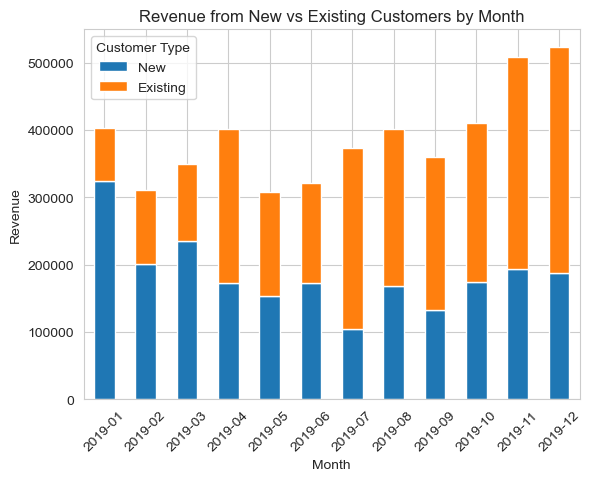

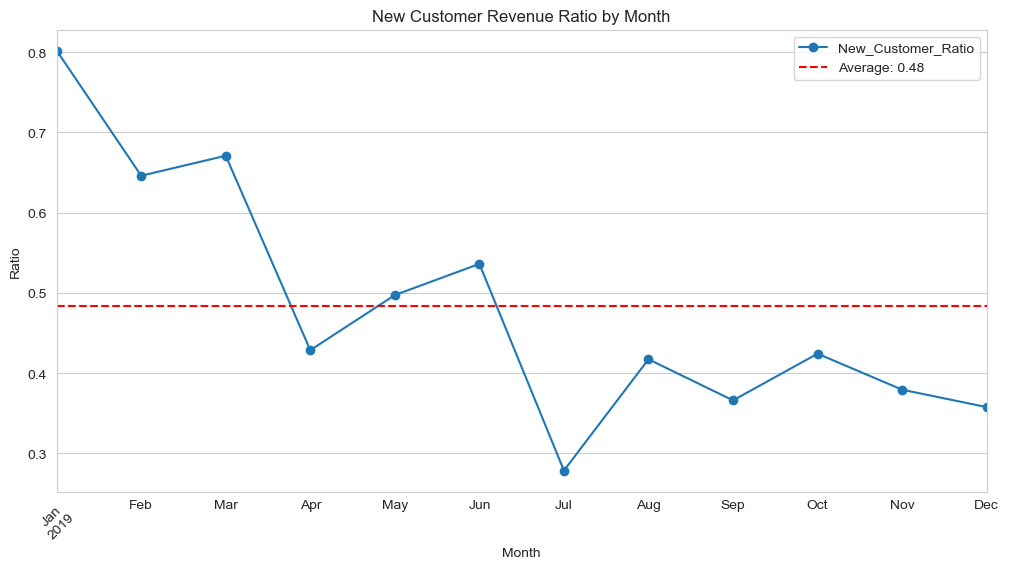


New Customer Revenue Ratio Statistics:
Mean: 48.38%
Median: 42.65%
Standard Deviation: 15.35%

Strategies for acquisition/retention balance:
1. New customer ratio is high (>40%) - Focus more on retention:
   - Implement loyalty programs with tiered rewards
   - Create subscription options for recurring revenue
   - Develop personalized recommendations for existing customers

2. For all scenarios:
   - Analyze customer lifetime value (LTV) by acquisition channel
   - Implement win-back campaigns for lapsed customers
   - Optimize onboarding process for new customers
   - Develop targeted upsell/cross-sell strategies for existing customers
   - Test different pricing and packaging options

Existing customer repeat rate: 50.00%


In [12]:
# Calculate first purchase date for each customer if not already present
if 'First_Purchase_Date' not in merged_data.columns:
    first_purchases = merged_data.groupby('CustomerID')['Transaction_Date'].min().reset_index()
    first_purchases.columns = ['CustomerID', 'First_Purchase_Date']
    merged_data = pd.merge(merged_data, first_purchases, on='CustomerID', how='left')

# Flag new vs existing customers in each transaction
merged_data['Customer_Type'] = np.where(
    merged_data['Transaction_Date'] == merged_data['First_Purchase_Date'],
    'New',
    'Existing'
)

# Calculate monthly revenue by customer type
revenue_by_type = merged_data.groupby(['YearMonth', 'Customer_Type'])['Revenue'].sum().unstack()

# Plot
plt.figure(figsize=(12, 6))
revenue_by_type[['New', 'Existing']].plot(kind='bar', stacked=True)
plt.title('Revenue from New vs Existing Customers by Month')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Customer Type')
plt.show()

# Calculate ratio
revenue_by_type['New_Customer_Ratio'] = revenue_by_type['New'] / (revenue_by_type['New'] + revenue_by_type['Existing'])

# Plot the ratio
plt.figure(figsize=(12, 6))
revenue_by_type['New_Customer_Ratio'].plot(kind='line', marker='o')
plt.title('New Customer Revenue Ratio by Month')
plt.ylabel('Ratio')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.axhline(y=revenue_by_type['New_Customer_Ratio'].mean(), color='r', linestyle='--', 
            label=f'Average: {revenue_by_type["New_Customer_Ratio"].mean():.2f}')
plt.legend()
plt.show()

# Calculate summary statistics
mean_ratio = revenue_by_type['New_Customer_Ratio'].mean()
median_ratio = revenue_by_type['New_Customer_Ratio'].median()
std_ratio = revenue_by_type['New_Customer_Ratio'].std()

print(f"\nNew Customer Revenue Ratio Statistics:")
print(f"Mean: {mean_ratio:.2%}")
print(f"Median: {median_ratio:.2%}")
print(f"Standard Deviation: {std_ratio:.2%}")

# Strategies
print("\nStrategies for acquisition/retention balance:")
if mean_ratio > 0.4:
    print("1. New customer ratio is high (>40%) - Focus more on retention:")
    print("   - Implement loyalty programs with tiered rewards")
    print("   - Create subscription options for recurring revenue")
    print("   - Develop personalized recommendations for existing customers")
else:
    print("1. New customer ratio is low (<=40%) - Focus more on acquisition:")
    print("   - Increase marketing spend on high-performing channels")
    print("   - Launch referral programs with incentives")
    print("   - Partner with complementary businesses for cross-promotion")

print("\n2. For all scenarios:")
print("   - Analyze customer lifetime value (LTV) by acquisition channel")
print("   - Implement win-back campaigns for lapsed customers")
print("   - Optimize onboarding process for new customers")
print("   - Develop targeted upsell/cross-sell strategies for existing customers")
print("   - Test different pricing and packaging options")

# Additional diagnostic metrics
existing_customer_repeat_rate = merged_data[merged_data['Customer_Type'] == 'Existing']['CustomerID'].nunique() / merged_data['CustomerID'].nunique()
print(f"\nExisting customer repeat rate: {existing_customer_repeat_rate:.2%}")

### 6) Analyze the relationship between coupon usage and revenue generation. How can discount strategies be optimized to maximize revenue while maintaining profitability?


Coupon usage analysis:
                 Revenue  Quantity  UniqueCustomers  Discount_pct  \
Coupon_Status                                                       
Clicked        88.288890  4.447746             1422     19.907186   
Not Used       90.525064  4.383741             1242     20.112136   
Used           87.177061  4.624162             1374     19.950501   

               Revenue_per_Customer  
Coupon_Status                        
Clicked                    0.062088  
Not Used                   0.072887  
Used                       0.063448  


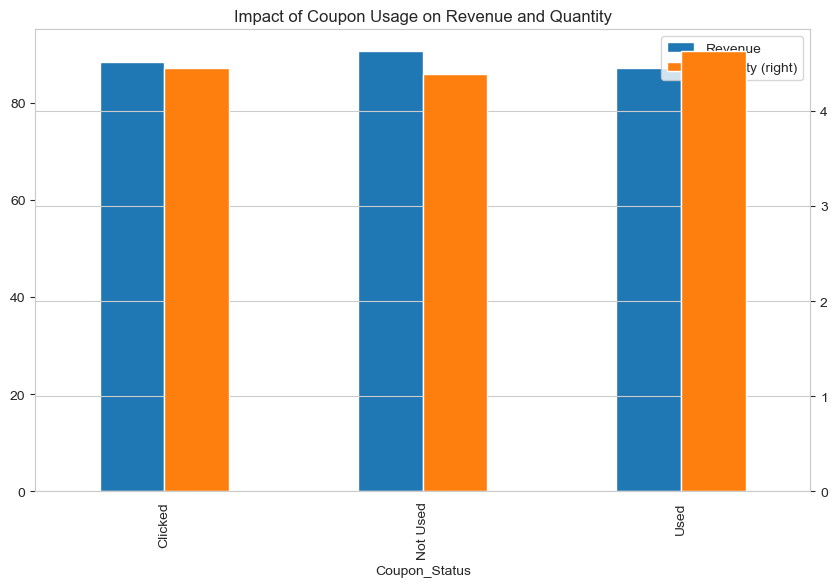


Coupon optimization strategies:
1. Test different discount levels to find the optimal balance between volume and margin
2. Implement targeted coupons rather than blanket discounts
3. Use coupons strategically to increase basket size (e.g., '$10 off $50+')
4. Analyze which product categories respond best to discounts
5. Consider time-limited coupons to create urgency


In [13]:
# Analyze coupon impact
coupon_analysis = merged_data.groupby('Coupon_Status').agg({
    'Revenue': 'mean',
    'Quantity': 'mean',
    'CustomerID': pd.Series.nunique,
    'Discount_pct': 'mean'
}).rename(columns={'CustomerID': 'UniqueCustomers'})

# Calculate revenue per customer
coupon_analysis['Revenue_per_Customer'] = coupon_analysis['Revenue'] / coupon_analysis['UniqueCustomers']

print("\nCoupon usage analysis:")
print(coupon_analysis)

# Plot
coupon_analysis[['Revenue', 'Quantity']].plot(kind='bar', secondary_y='Quantity', figsize=(10, 6))
plt.title('Impact of Coupon Usage on Revenue and Quantity')
plt.show()

# Strategies
print("\nCoupon optimization strategies:")
print("1. Test different discount levels to find the optimal balance between volume and margin")
print("2. Implement targeted coupons rather than blanket discounts")
print("3. Use coupons strategically to increase basket size (e.g., '$10 off $50+')")
print("4. Analyze which product categories respond best to discounts")
print("5. Consider time-limited coupons to create urgency")

### 7)Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?


Top performing products:
                                                      Revenue  Quantity  \
Product_Description                                                       
Nest Learning Thermostat 3rd Gen-USA - Stainles...  688916.34      4570   
Nest Cam Outdoor Security Camera - USA              629977.12      5206   
Nest Cam Indoor Security Camera - USA               528612.93      4402   
Nest Protect Smoke + CO White Battery Alarm-USA     213819.16      2683   
Nest Protect Smoke + CO White Wired Alarm-USA       212495.57      2670   
Nest Learning Thermostat 3rd Gen-USA - White        204666.40      1368   
Nest Secure Alarm System Starter Pack - USA         179142.54       510   
Nest Cam IQ - USA                                   154112.52       771   
Nest Thermostat E - USA                             108704.24      1091   
Nest Learning Thermostat 3rd Gen-USA - Copper        70604.48       472   

                                                    CustomerID   Avg_Pric

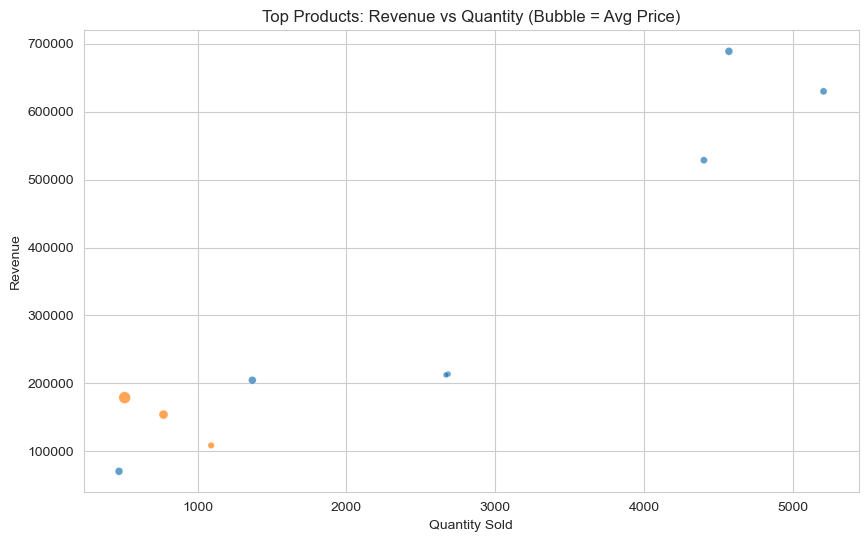

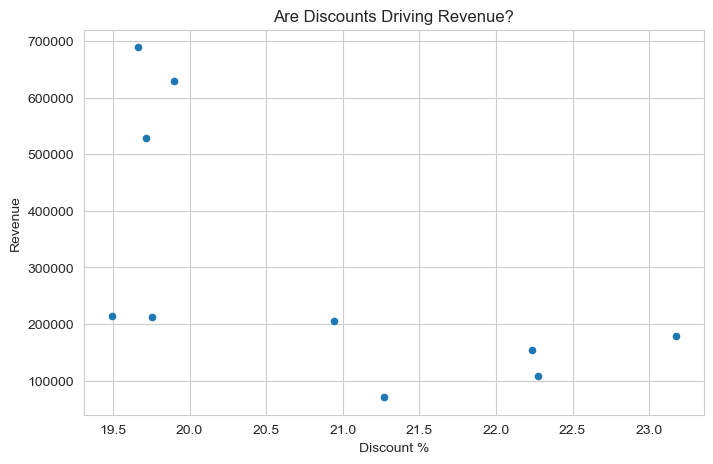


Inventory and promotion strategies:
1. Ensure adequate stock of top-performing products, especially before peak seasons
2. Use top products as 'loss leaders' to attract customers to complementary items
3. Analyze pricing elasticity of top products to optimize margins
4. Bundle slower-moving products with top sellers
5. Highlight top products in marketing materials and on the website


In [14]:
# Identify top products by revenue
top_products = merged_data.groupby('Product_Description').agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'CustomerID': pd.Series.nunique
}).sort_values('Revenue', ascending=False).head(10)

# Analyze characteristics of top products
top_product_chars = merged_data[merged_data['Product_Description'].isin(top_products.index)].groupby('Product_Description').agg({
    'Avg_Price': 'mean',
    'Discount_pct': 'mean',
    'Product_Category': 'first',
    'GST': 'mean'
})

print("\nTop performing products:")
print(top_products.join(top_product_chars))

merged_top = top_products.join(top_product_chars)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged_top,
    x='Quantity',
    y='Revenue',
    size='Avg_Price',
    hue='Product_Category',
    legend=False,
    alpha=0.7
)
plt.title("Top Products: Revenue vs Quantity (Bubble = Avg Price)")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")
plt.show()

merged_top.plot(kind='scatter', x='Discount_pct', y='Revenue', figsize=(8, 5))
plt.title("Are Discounts Driving Revenue?")
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()



# Strategies
print("\nInventory and promotion strategies:")
print("1. Ensure adequate stock of top-performing products, especially before peak seasons")
print("2. Use top products as 'loss leaders' to attract customers to complementary items")
print("3. Analyze pricing elasticity of top products to optimize margins")
print("4. Bundle slower-moving products with top sellers")
print("5. Highlight top products in marketing materials and on the website")

### 8)Analyze the relationship between monthly marketing spend and revenue. Are there any months where marketing efforts yielded disproportionately high or low returns? How can marketing strategies be adjusted to improve ROI?

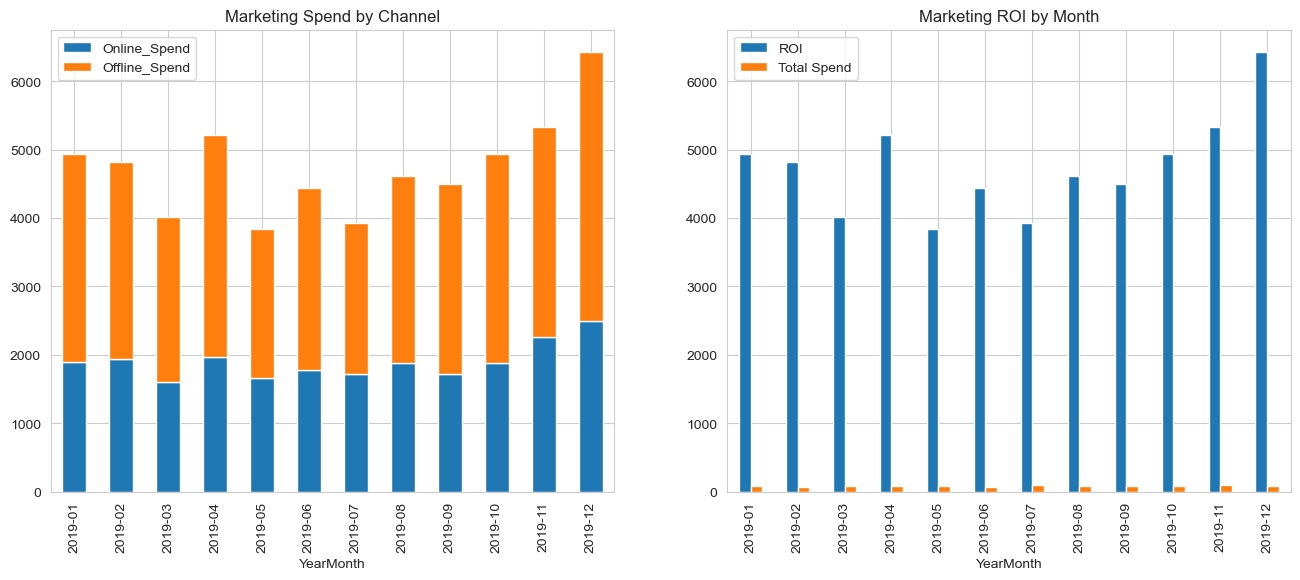

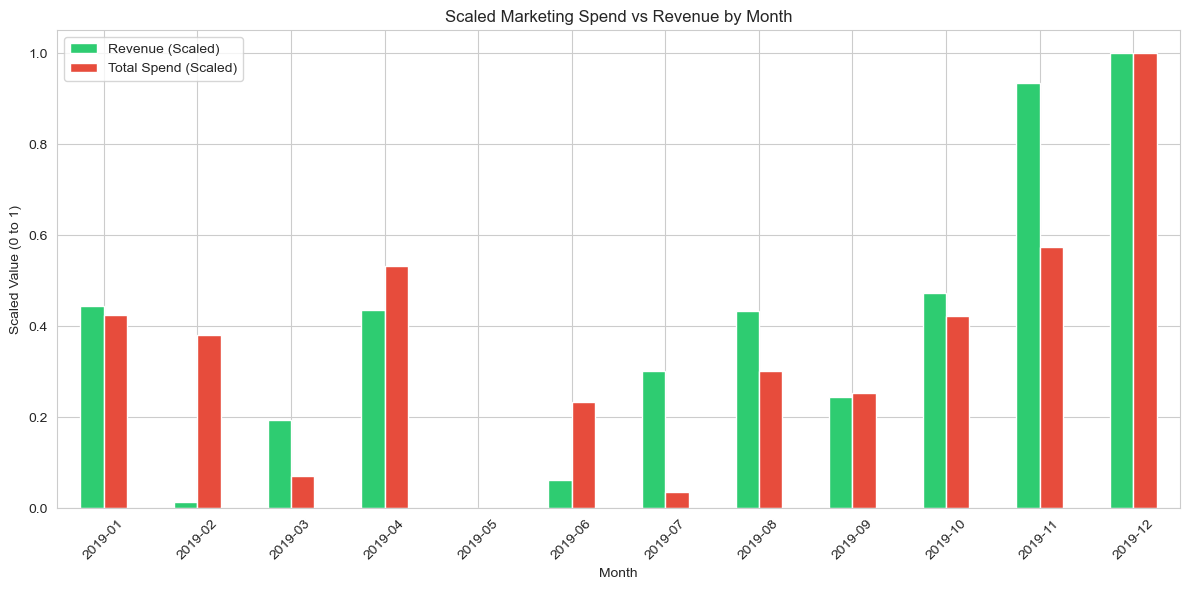


 Highest ROI :  YearMonth
2019-11    95.558072
2019-07    94.899303
2019-03    87.052589
Freq: M, Name: ROI, dtype: float64

 Lowest ROI :  YearMonth
2019-02    64.433917
2019-06    72.282687
2019-04    76.963541
Freq: M, Name: ROI, dtype: float64

Marketing optimization strategies:
1. Reallocate budget from low-ROI months/channels to high-ROI ones
2. Analyze what made high-ROI months successful and replicate those strategies
3. Test different marketing mixes to find optimal channel allocation
4. Consider attribution modeling to better understand touchpoints in customer journey
5. Implement more aggressive remarketing during high-ROI periods


In [15]:
# Aggregate marketing spend and revenue by month
marketing_roi = merged_data.groupby('YearMonth').agg({
    'Online_Spend': 'mean',
    'Offline_Spend': 'mean',
    'Revenue': 'sum'
})

# Calculate ROI
marketing_roi['Total_Spend'] = marketing_roi['Online_Spend'] + marketing_roi['Offline_Spend']
marketing_roi['ROI'] = marketing_roi['Revenue'] / marketing_roi['Total_Spend']

# Plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
marketing_roi[['Online_Spend', 'Offline_Spend']].plot(kind='bar', stacked=True, ax=ax[0], title='Marketing Spend by Channel')
marketing_roi[['Total_Spend','ROI']].plot(kind='bar', ax=ax[1], title='Marketing ROI by Month')
ax[1].legend(['ROI', 'Total Spend'])
plt.show()

spend_vs_revenue = marketing_roi[['Revenue', 'Total_Spend']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(spend_vs_revenue[['Revenue', 'Total_Spend']])

# 3. Create DataFrame for plotting
scaled_df = pd.DataFrame(
    scaled_data, 
    columns=['Revenue (Scaled)', 'Total Spend (Scaled)'], 
    index=marketing_roi.index
)

# 4. Plot the scaled values
scaled_df.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Scaled Marketing Spend vs Revenue by Month')
plt.ylabel('Scaled Value (0 to 1)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Identify high and low ROI months
high_roi = marketing_roi['ROI'].nlargest(3)
low_roi = marketing_roi['ROI'].nsmallest(3)
print("\n Highest ROI : ",high_roi)
print("\n Lowest ROI : ",low_roi)


# Strategies
print("\nMarketing optimization strategies:")
print("1. Reallocate budget from low-ROI months/channels to high-ROI ones")
print("2. Analyze what made high-ROI months successful and replicate those strategies")
print("3. Test different marketing mixes to find optimal channel allocation")
print("4. Consider attribution modeling to better understand touchpoints in customer journey")
print("5. Implement more aggressive remarketing during high-ROI periods")

### 9) Evaluate the effectiveness of marketing campaigns by comparing marketing spend to revenue generated. Are there opportunities to reallocate resources for better results?


Correlation between marketing spend and revenue:
               Online_Spend  Offline_Spend   Revenue
Online_Spend       1.000000       0.880384  0.859174
Offline_Spend      0.880384       1.000000  0.747100
Revenue            0.859174       0.747100  1.000000


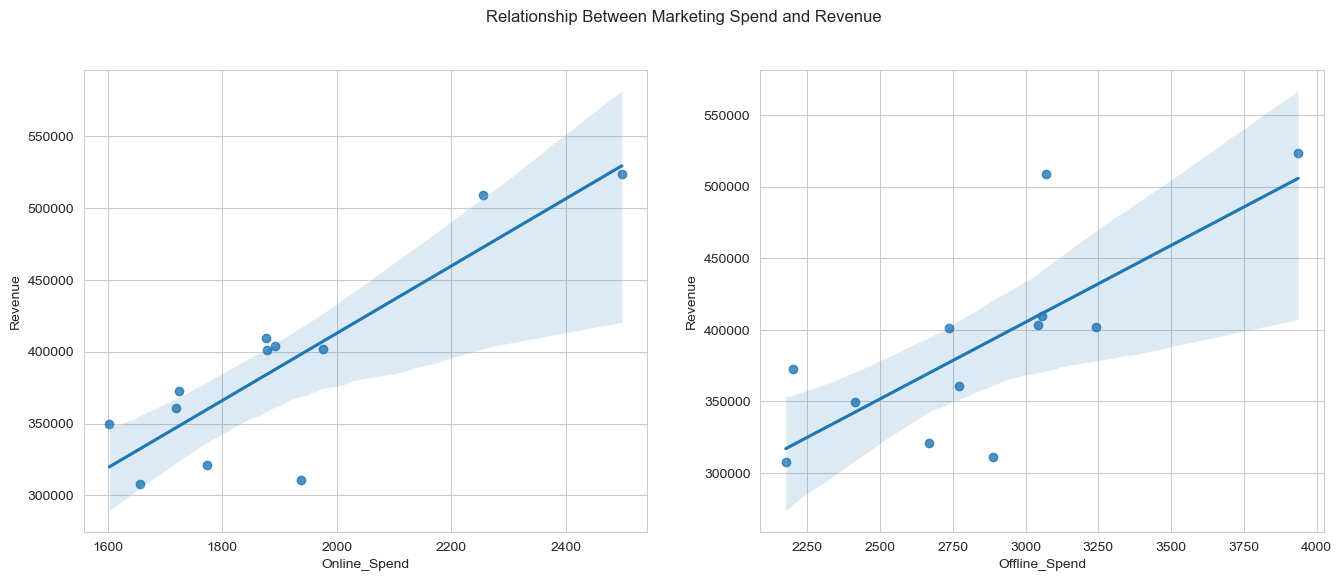


Marketing resource allocation strategies:
1. Increase investment in channels with highest correlation to revenue
2. Test reducing spend in low-correlation channels to determine true impact
3. Implement multi-touch attribution to better understand channel interactions
4. Consider longer-term brand-building activities that may not show immediate ROI
5. Allocate budget to channels that drive both acquisition and retention


In [16]:
# Calculate correlation between spend and revenue
correlation = marketing_roi[['Online_Spend', 'Offline_Spend', 'Revenue']].corr()

print("\nCorrelation between marketing spend and revenue:")
print(correlation)

# Plot scatter plots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(x='Online_Spend', y='Revenue', data=marketing_roi, ax=ax[0])
sns.regplot(x='Offline_Spend', y='Revenue', data=marketing_roi, ax=ax[1])
plt.suptitle('Relationship Between Marketing Spend and Revenue')
plt.show()

# Strategies
print("\nMarketing resource allocation strategies:")
print("1. Increase investment in channels with highest correlation to revenue")
print("2. Test reducing spend in low-correlation channels to determine true impact")
print("3. Implement multi-touch attribution to better understand channel interactions")
print("4. Consider longer-term brand-building activities that may not show immediate ROI")
print("5. Allocate budget to channels that drive both acquisition and retention")

### 10) Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)

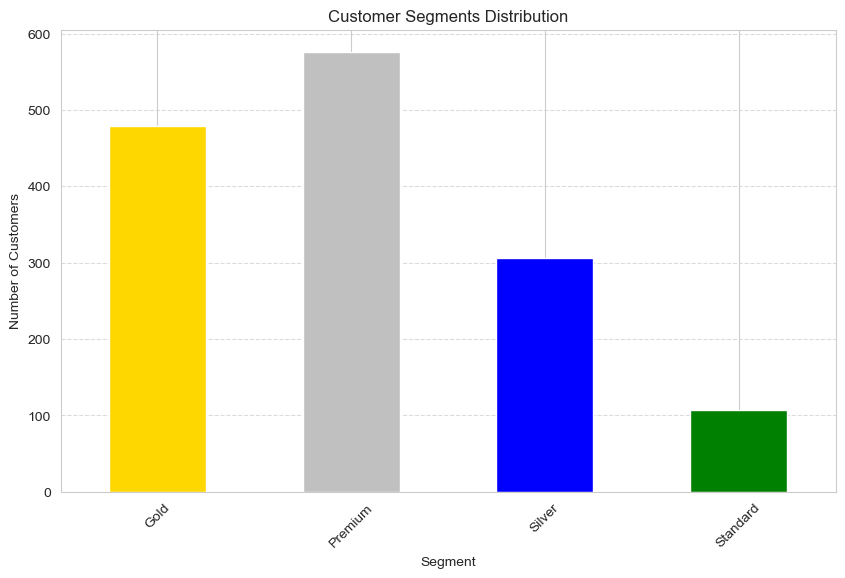


Segment Distribution:
Gold        479
Premium     576
Silver      306
Standard    107
Name: Segment, dtype: int64

Percentage Distribution:
Gold        0.326
Premium     0.392
Silver      0.208
Standard    0.073
Name: Segment, dtype: float64

Segment Metrics:
          Avg_Recency  Avg_Frequency  Avg_Revenue  Avg_RFM_Score
Segment                                                         
Gold           145.78          20.29      1592.58           6.94
Premium         90.22          69.74      6446.36          10.31
Silver         197.93           8.64       563.37           4.54
Standard       289.04           3.64       209.87           3.00

Segment-specific strategies:

1. Premium Segment (Top 25%):
   - Exclusive VIP programs with early access to new products
   - Personalized concierge service
   - High-touch relationship management
   - Invitation-only events and experiences

2. Gold Segment (Next 25%):
   - Loyalty rewards program with tiered benefits
   - Targeted upsell campai

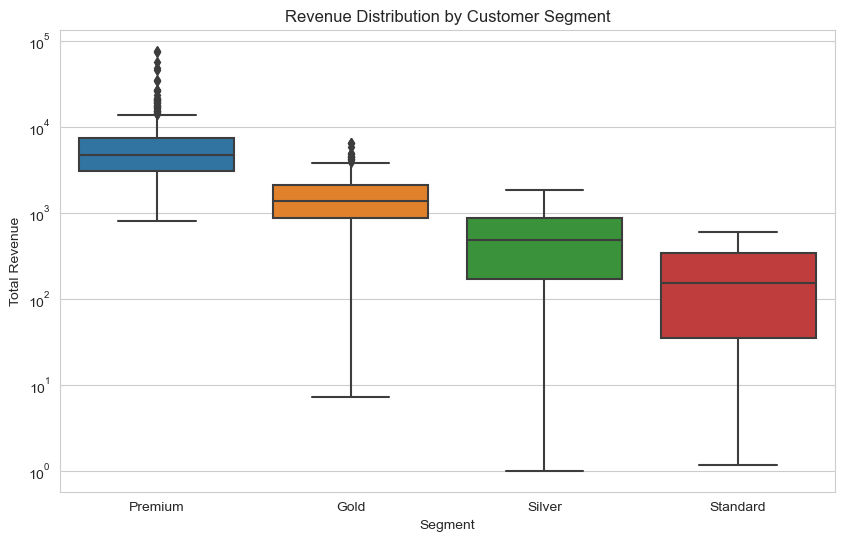

In [17]:
# Calculate RFM metrics
current_date = merged_data['Transaction_Date'].max() + pd.Timedelta(days=1)
rfm = merged_data.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (current_date - x.max()).days,  # Recency
    'Transaction_ID': 'count',  # Frequency
    'Revenue': 'sum'  # Monetary
}).rename(columns={
    'Transaction_Date': 'Recency',
    'Transaction_ID': 'Frequency',
    'Revenue': 'Monetary'
})

# Create RFM segments using quantiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Convert scores to numeric
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Calculate RFM score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Define segments using direct mapping instead of regex
def assign_segment(score):
    if score >= 9:
        return 'Premium'
    elif score >= 6:
        return 'Gold'
    elif score >= 4:
        return 'Silver'
    else:
        return 'Standard'

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

# Plot segments
plt.figure(figsize=(10, 6))
segment_counts = rfm['Segment'].value_counts().sort_index()
segment_counts.plot(kind='bar', color=['gold', 'silver', 'blue', 'green'])
plt.title('Customer Segments Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print segment distribution
print("\nSegment Distribution:")
print(segment_counts)
print("\nPercentage Distribution:")
print((segment_counts / segment_counts.sum()).round(3))

# Calculate segment metrics
segment_metrics = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'RFM_Score': 'mean'
}).rename(columns={
    'Recency': 'Avg_Recency',
    'Frequency': 'Avg_Frequency',
    'Monetary': 'Avg_Revenue',
    'RFM_Score': 'Avg_RFM_Score'
})

print("\nSegment Metrics:")
print(segment_metrics.round(2))

# Strategies for each segment
print("\nSegment-specific strategies:")
print("\n1. Premium Segment (Top 25%):")
print("   - Exclusive VIP programs with early access to new products")
print("   - Personalized concierge service")
print("   - High-touch relationship management")
print("   - Invitation-only events and experiences")

print("\n2. Gold Segment (Next 25%):")
print("   - Loyalty rewards program with tiered benefits")
print("   - Targeted upsell campaigns")
print("   - Personalized product recommendations")
print("   - Special anniversary offers")

print("\n3. Silver Segment (Next 25%):")
print("   - Win-back campaigns for lapsing customers")
print("   - Reactivation offers with time-sensitive discounts")
print("   - Educational content about product benefits")
print("   - Cross-sell opportunities based on past purchases")

print("\n4. Standard Segment (Bottom 25%):")
print("   - New customer onboarding programs")
print("   - Entry-level product bundles")
print("   - Customer satisfaction surveys")
print("   - Value-focused messaging")

# Additional analysis - monetary value by segment
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='Monetary', data=rfm, order=['Premium', 'Gold', 'Silver', 'Standard'])
plt.title('Revenue Distribution by Customer Segment')
plt.ylabel('Total Revenue')
plt.xlabel('Segment')
plt.yscale('log')  
plt.show()

### 11) Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?


Revenue by segment:
          Total_Revenue  Avg_Revenue_per_Order  Order_Count  Unique_Customers  \
Segment                                                                         
Premium      3713103.28              92.430132        40172               576   
Gold          762844.82              78.481977         9720               479   
Silver        172390.03              65.225134         2643               306   
Standard       22456.49              57.728766          389               107   

          Pct_of_Total_Revenue  Avg_Revenue_per_Customer  Orders_per_Customer  
Segment                                                                        
Premium               0.794962               6446.359861            69.743056  
Gold                  0.163322               1592.577912            20.292276  
Silver                0.036908                563.366111             8.637255  
Standard              0.004808                209.873738             3.635514  


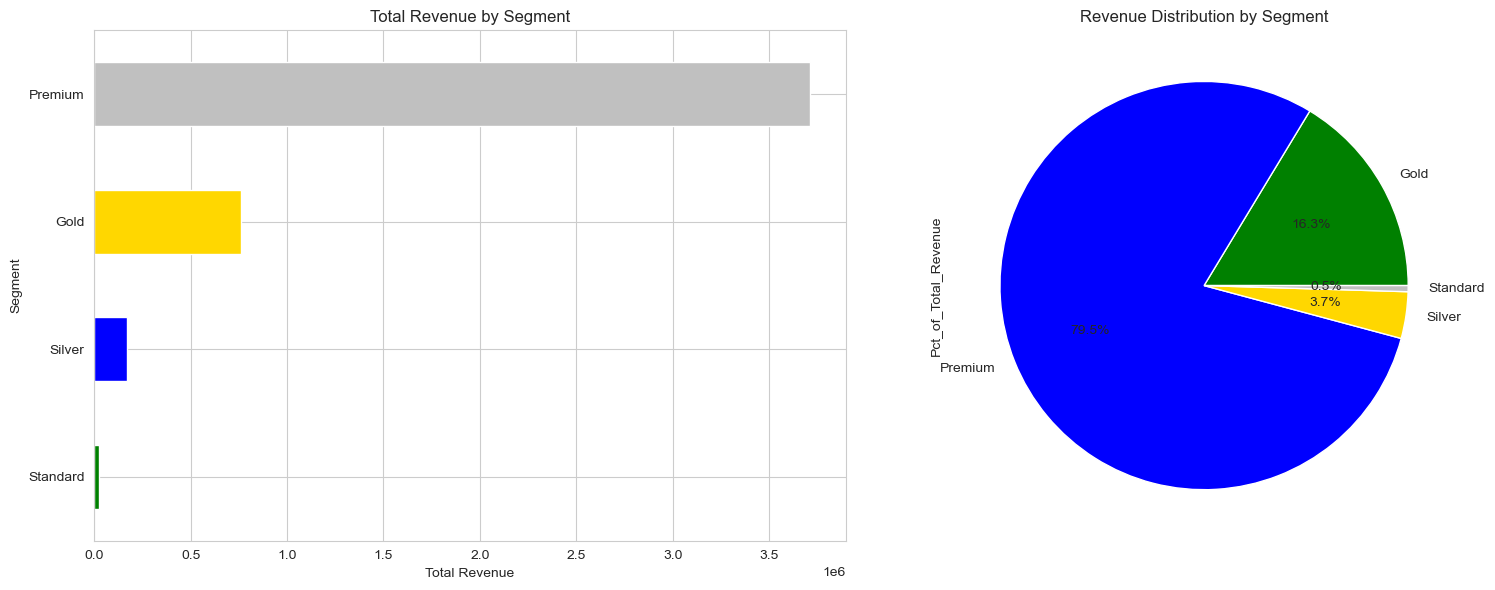


Segment-focused strategies:

Gold (16.3% of revenue):
   - Loyalty rewards program
   - Subscription options
   - Personalized recommendations

Premium (79.5% of revenue):
   - Dedicated account managers
   - Exclusive early access to new products
   - High-touch customer service

Silver (3.7% of revenue):
   - Win-back campaigns
   - Limited-time upgrade offers
   - Educational content

Standard (0.5% of revenue):
   - New customer onboarding
   - Entry-level bundles
   - Satisfaction guarantees


In [18]:

# Now merge segments back to transaction data (using reset_index() to ensure CustomerID is a column)
merged_data = merged_data.merge(
    rfm['Segment'].reset_index(), 
    on='CustomerID', 
    how='left'
)

# Handle any missing segments by assigning 'Standard' category
merged_data['Segment'] = merged_data['Segment'].fillna('Standard')

# Calculate revenue by segment
segment_stats = merged_data.groupby('Segment').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'CustomerID': pd.Series.nunique
})

# Create a clean DataFrame for display
segment_revenue = pd.DataFrame({
    'Total_Revenue': segment_stats[('Revenue', 'sum')],
    'Avg_Revenue_per_Order': segment_stats[('Revenue', 'mean')],
    'Order_Count': segment_stats[('Revenue', 'count')],
    'Unique_Customers': segment_stats[('CustomerID', 'nunique')]
})

# Calculate derived metrics
segment_revenue['Pct_of_Total_Revenue'] = segment_revenue['Total_Revenue'] / segment_revenue['Total_Revenue'].sum()
segment_revenue['Avg_Revenue_per_Customer'] = segment_revenue['Total_Revenue'] / segment_revenue['Unique_Customers']
segment_revenue['Orders_per_Customer'] = segment_revenue['Order_Count'] / segment_revenue['Unique_Customers']

print("\nRevenue by segment:")
print(segment_revenue.sort_values('Total_Revenue', ascending=False))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Total Revenue by Segment
segment_revenue['Total_Revenue'].sort_values().plot(
    kind='barh', 
    ax=ax[0], 
    color=['green', 'blue', 'gold', 'silver'],
    title='Total Revenue by Segment'
)
ax[0].set_xlabel('Total Revenue')

# Revenue Distribution by Segment
segment_revenue['Pct_of_Total_Revenue'].plot(
    kind='pie', 
    ax=ax[1], 
    autopct='%1.1f%%', 
    colors=['green', 'blue', 'gold', 'silver'],
    title='Revenue Distribution by Segment'
)

plt.tight_layout()
plt.show()

# Strategies
print("\nSegment-focused strategies:")
for segment in segment_revenue.index:
    pct = segment_revenue.loc[segment, 'Pct_of_Total_Revenue']
    print(f"\n{segment} ({pct:.1%} of revenue):")
    
    if segment == 'Premium':
        print("   - Dedicated account managers")
        print("   - Exclusive early access to new products")
        print("   - High-touch customer service")
    elif segment == 'Gold':
        print("   - Loyalty rewards program")
        print("   - Subscription options")
        print("   - Personalized recommendations")
    elif segment == 'Silver':
        print("   - Win-back campaigns")
        print("   - Limited-time upgrade offers")
        print("   - Educational content")
    else:  # Standard
        print("   - New customer onboarding")
        print("   - Entry-level bundles")
        print("   - Satisfaction guarantees")

### 12) Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?

retention_matrix                                      Month 0   Month 1   Month 2   Month 3  \
first_transaction_month_of_customer                                          
2019-01                                  1.0  0.060465  0.111628  0.158140   
2019-02                                  1.0  0.072917  0.093750  0.166667   
2019-03                                  1.0  0.101695  0.197740  0.141243   
2019-04                                  1.0  0.085890  0.147239  0.147239   
2019-05                                  1.0  0.107143  0.080357  0.116071   
2019-06                                  1.0  0.145985  0.160584  0.087591   
2019-07                                  1.0  0.138298  0.042553  0.063830   
2019-08                                  1.0  0.103704  0.111111  0.074074   
2019-09                                  1.0  0.076923  0.038462  0.025641   
2019-10                                  1.0  0.068966  0.045977       NaN   
2019-11                                  1.0  0

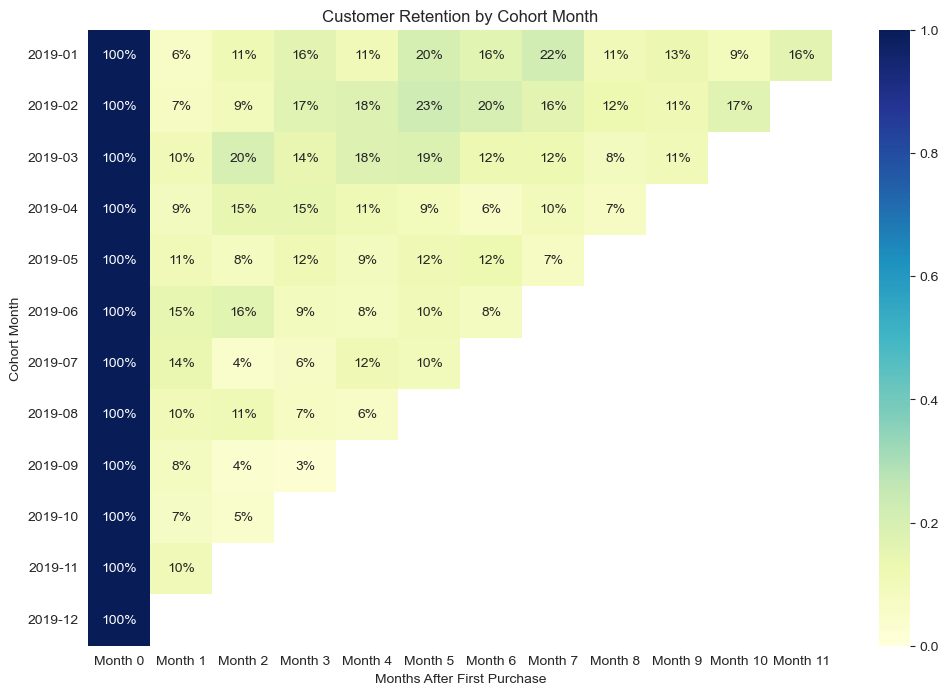


Best performing cohort: 2019-12 with 100.0% average retention
Worst performing cohort: 2019-04 with 20.2% average retention


In [19]:
print("retention_matrix",retention_matrix)

# Plot retention heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.0%', 
            cmap='YlGnBu',
            vmin=0.0,
            vmax=1.0)
plt.title('Customer Retention by Cohort Month')
plt.ylabel('Cohort Month')
plt.xlabel('Months After First Purchase')
plt.yticks(rotation=0)
plt.show()

# Identify best and worst cohorts
avg_retention = retention_matrix.mean(axis=1)
best_cohort = avg_retention.idxmax()
worst_cohort = avg_retention.idxmin()

print(f"\nBest performing cohort: {best_cohort} with {avg_retention.max():.1%} average retention")
print(f"Worst performing cohort: {worst_cohort} with {avg_retention.min():.1%} average retention")

### 13) Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?



Customer Lifetime Value by Acquisition Month:
               Revenue           Transaction_ID       
                  mean    median           mean median
YearMonth                                             
2019-01    1877.323628  1145.110      18.897674   13.0
2019-02    2851.557798  1982.030      30.128440   23.0
2019-03    1680.808125  1089.950      20.894231   14.0
2019-04    1792.939375   718.280      18.526786   12.0
2019-05    1538.817100   972.630      22.860000   16.5
2019-06    1239.696448   828.450      16.189189   12.0
2019-07    1578.974873   758.855      22.250000   15.0
2019-08    1337.367900   753.740      20.500000   14.0
2019-09    1868.126425  1108.000      22.217617   16.0
2019-10    1950.863238  1094.975      19.828571   12.0
2019-11    2707.141596  2013.670      21.069149   17.0
2019-12    2217.195720  1272.670      19.076271   13.0


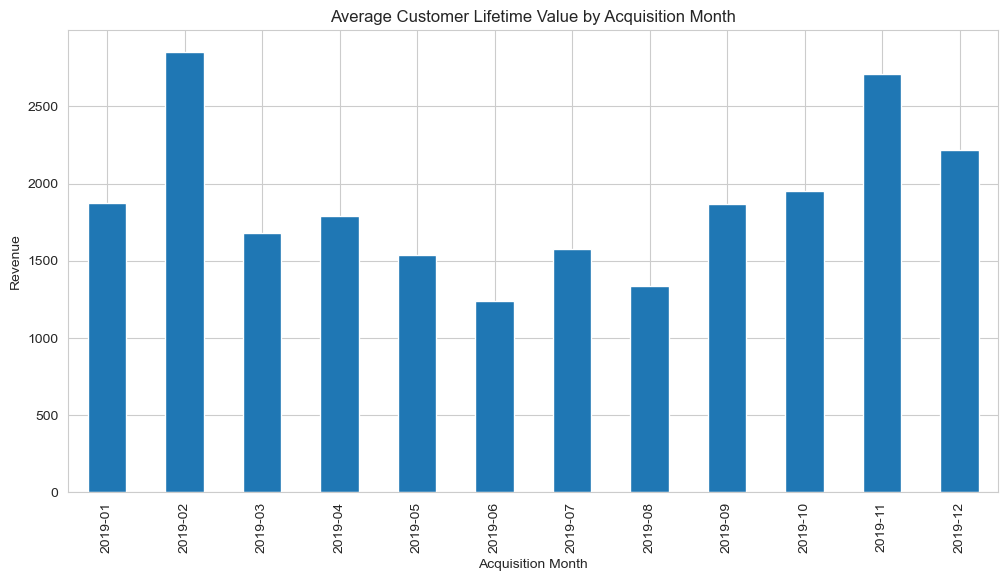


CLV-based strategies:
1. Focus acquisition efforts on months that yield higher CLV customers
2. Analyze what drives higher CLV in certain months and replicate those conditions
3. For low-CLV months: Implement early engagement strategies to increase value
4. Adjust marketing mix based on CLV performance by channel
5. Develop different onboarding flows for high vs low CLV cohorts


In [20]:
# Calculate CLV by cohort
clv = merged_data.groupby(['YearMonth', 'CustomerID']).agg({
    'Revenue': 'sum',
    'Transaction_ID': 'count'
}).groupby('YearMonth').agg({
    'Revenue': ['mean', 'median'],
    'Transaction_ID': ['mean', 'median']
})

print("\nCustomer Lifetime Value by Acquisition Month:")
print(clv)

# Plot
clv['Revenue']['mean'].plot(kind='bar', figsize=(12, 6))
plt.title('Average Customer Lifetime Value by Acquisition Month')
plt.ylabel('Revenue')
plt.xlabel('Acquisition Month')
plt.show()

# Strategies
print("\nCLV-based strategies:")
print("1. Focus acquisition efforts on months that yield higher CLV customers")
print("2. Analyze what drives higher CLV in certain months and replicate those conditions")
print("3. For low-CLV months: Implement early engagement strategies to increase value")
print("4. Adjust marketing mix based on CLV performance by channel")
print("5. Develop different onboarding flows for high vs low CLV cohorts")


### 14) Do customers who use coupons have a different average transaction value compared to those who do not? Conduct a statistical test to validate this hypothesis. What implications does this have for the company’s discount and coupon strategies?

In [21]:
# Compare transaction values
coupon_vs_non = merged_data.groupby('Coupon_Status')['Revenue'].describe()

print("\nTransaction value comparison:")
print(coupon_vs_non)

# Statistical test
used = merged_data[merged_data['Coupon_Status'] == 'Used']['Revenue']
not_used = merged_data[merged_data['Coupon_Status'] == 'Not Used']['Revenue']
t_stat, p_value = stats.ttest_ind(used, not_used, equal_var=False)

print(f"\nT-test results: t-statistic={t_stat:.2f}, p-value={p_value:.4f}"+"\nNote: t-statistic: How much the two groups differ relative to variation. p-value: Probability that the difference is due to random chance.A low p-value (usually < 0.05) suggests a statistically significant difference in transaction values between the two groups.")

# Strategies
print("\nCoupon strategy implications:")
print("1. If coupon users have higher transaction values: Consider expanding coupon programs")
print("2. If coupon users have lower transaction values: Implement minimum spend requirements")
print("3. Test different coupon designs (percentage vs fixed amount)")
print("4. Analyze whether coupons are attracting price-sensitive customers who wouldn't buy otherwise")
print("5. Implement dynamic couponing based on customer behavior and predicted response")


Transaction value comparison:
                 count       mean         std  min    25%    50%    75%  \
Coupon_Status                                                             
Clicked        26926.0  88.288890  155.035858  0.4  12.00  31.17  120.0   
Not Used        8094.0  90.525064  173.384624  0.4  11.95  30.39  121.3   
Used           17904.0  87.177061  172.507097  0.4  11.75  30.00  121.3   

                    max  
Coupon_Status            
Clicked         7495.00  
Not Used        5996.00  
Used           10512.39  

T-test results: t-statistic=-1.44, p-value=0.1488
Note: t-statistic: How much the two groups differ relative to variation. p-value: Probability that the difference is due to random chance.A low p-value (usually < 0.05) suggests a statistically significant difference in transaction values between the two groups.

Coupon strategy implications:
1. If coupon users have higher transaction values: Consider expanding coupon programs
2. If coupon users have lower tr

### 15) Do purchase behaviors (e.g., order frequency, order value) vary significantly across different demographic groups or pricing factors (e.g., delivery charges)?Test for differences in purchase behavior across locations, age groups, or delivery charge tiers. How can these insights inform personalized marketing and pricing strategies?

In [22]:
# Analyze by location
location_analysis = merged_data.groupby('Location').agg({
    'Revenue': 'mean',
    'Quantity': 'mean',
    'CustomerID': pd.Series.nunique
}).rename(columns={'CustomerID': 'UniqueCustomers'})
print("location_analysis",location_analysis)
# Analyze by gender
gender_analysis = merged_data.groupby('Gender').agg({
    'Revenue': 'mean',
    'Quantity': 'mean',
    'Avg_Price': 'mean'
})
print("gender_analysis",gender_analysis)


print("\nPurchase behavior by location:")
print(location_analysis)
print("\nPurchase behavior by gender:")
print(gender_analysis)

# Statistical tests
# ANOVA for location
locations = merged_data['Location'].unique()
location_groups = [merged_data[merged_data['Location'] == loc]['Revenue'] for loc in locations]
f_stat, p_value = stats.f_oneway(*location_groups)
print(f"\nANOVA for revenue by location: F-statistic={f_stat:.2f}, p-value={p_value:.4f}")

# T-test for gender
male = merged_data[merged_data['Gender'] == 'M']['Revenue']
female = merged_data[merged_data['Gender'] == 'F']['Revenue']
t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)
print(f"T-test for revenue by gender: t-statistic={t_stat:.2f}, p-value={p_value:.4f}")

print("\nNOTE : ANOVA (Analysis of Variance) tests whether the mean revenue differs significantly across multiple groups (here, locations). It compares the variance between groups (locations) to the variance within groups.Outputs:F-statistic: Ratio of between-group variance to within-group variance.p-value: Probability that observed differences happened by chance.\n")

# Strategies
print("\nPersonalization strategies:")
print("1. Tailor product recommendations based on location preferences")
print("2. Adjust marketing messaging by demographic segments")
print("3. Localize promotions based on regional buying patterns")
print("4. Test different pricing or delivery options by region")
print("5. Develop targeted product bundles for different demographics")

location_analysis                  Revenue  Quantity  UniqueCustomers
Location                                           
California     89.393115  4.497831              464
Chicago        88.459498  4.568498              456
New Jersey     90.976429  5.035976              149
New York       83.864909  4.162445              324
Washington DC  93.620878  4.503294               75
gender_analysis           Revenue  Quantity  Avg_Price
Gender                                
F       87.971346  4.604205  51.613537
M       88.724426  4.321032  53.271938

Purchase behavior by location:
                 Revenue  Quantity  UniqueCustomers
Location                                           
California     89.393115  4.497831              464
Chicago        88.459498  4.568498              456
New Jersey     90.976429  5.035976              149
New York       83.864909  4.162445              324
Washington DC  93.620878  4.503294               75

Purchase behavior by gender:
          Revenue  Q

### 16) Does customer tenure impact purchase frequency?Analyze the relationship between customer tenure and purchase frequency. How can this insight be used to improve customer engagement and retention strategies?


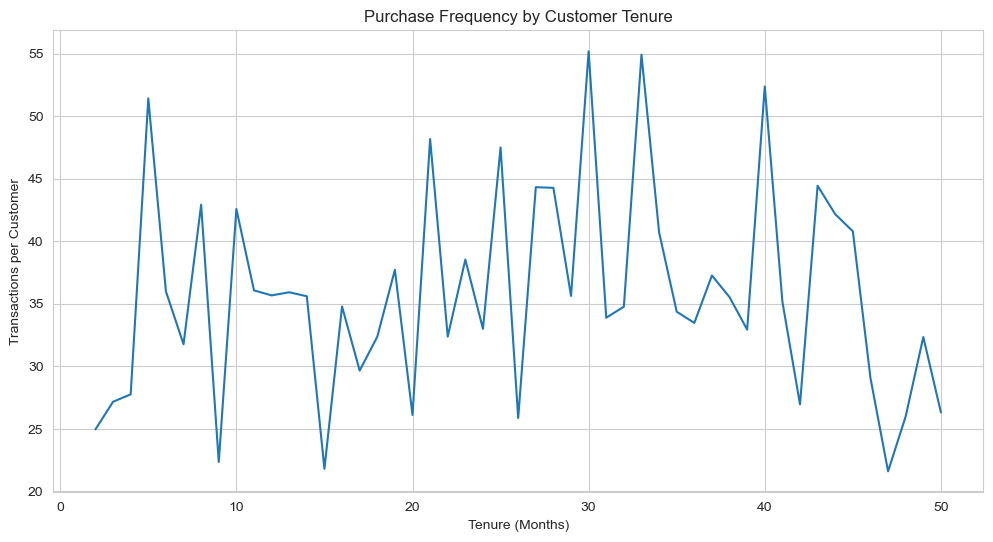


Correlation between tenure and purchase frequency: 0.11

Tenure-based engagement strategies:
1. For new customers: Focus on onboarding and first purchase experience
2. For mid-tenure customers: Implement loyalty programs to maintain engagement
3. For long-tenure customers: Reward loyalty and encourage referrals
4. Identify drop-off points and implement re-engagement campaigns
5. Develop lifecycle marketing programs tailored to tenure stages


In [23]:
# Group by tenure and calculate frequency
tenure_freq = merged_data.groupby('Tenure_Months').agg({
    'Transaction_ID': 'count',
    'CustomerID': pd.Series.nunique
}).rename(columns={'Transaction_ID': 'TotalTransactions', 'CustomerID': 'UniqueCustomers'})
tenure_freq['Transactions_per_Customer'] = tenure_freq['TotalTransactions'] / tenure_freq['UniqueCustomers']

# Plot
tenure_freq['Transactions_per_Customer'].plot(kind='line', figsize=(12, 6))
plt.title('Purchase Frequency by Customer Tenure')
plt.ylabel('Transactions per Customer')
plt.xlabel('Tenure (Months)')
plt.show()

# Correlation
corr = tenure_freq['Transactions_per_Customer'].corr(pd.Series(tenure_freq.index))
print(f"\nCorrelation between tenure and purchase frequency: {corr:.2f}")

# Strategies
print("\nTenure-based engagement strategies:")
print("1. For new customers: Focus on onboarding and first purchase experience")
print("2. For mid-tenure customers: Implement loyalty programs to maintain engagement")
print("3. For long-tenure customers: Reward loyalty and encourage referrals")
print("4. Identify drop-off points and implement re-engagement campaigns")
print("5. Develop lifecycle marketing programs tailored to tenure stages")

### 17) Analyze the relationship between delivery charges and order behavior. Are there opportunities to optimize delivery pricing to increase order quantities or revenue?


In [24]:
# Analyze delivery charge impact
delivery_analysis = merged_data.groupby('Delivery_Charges').agg({
    'Revenue': 'mean',
    'Quantity': 'mean',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'TransactionCount'})

# Calculate free shipping threshold behavior
merged_data['Above_Threshold'] = merged_data['Revenue'] > merged_data['Revenue'].median()
threshold_behavior = merged_data.groupby(['Delivery_Charges', 'Above_Threshold']).size().unstack()

print("\nDelivery charge analysis:")
print(delivery_analysis)
print("\nBehavior above/below revenue threshold:")
print(threshold_behavior)

# Strategies
print("\nDelivery pricing strategies:")
print("1. Test free shipping thresholds to find optimal balance between cost and conversion")
print("2. Offer free shipping as a loyalty benefit for high-value customers")
print("3. Implement conditional free shipping (e.g., for specific products or order sizes)")
print("4. Communicate delivery costs clearly early in checkout process")
print("5. Test bundling delivery costs into product prices for psychological effect")


Delivery charge analysis:
                      Revenue    Quantity  TransactionCount
Delivery_Charges                                           
0.00               120.661975    1.314815               162
6.00                77.456471    2.981195             26801
6.46                32.990000    1.000000                14
6.48                14.662069    3.172414                29
6.50               102.037783    3.430179             15819
...                       ...         ...               ...
354.00             343.070000   13.000000                 3
422.24             652.857500   82.250000                 4
492.84             135.847000   12.100000                10
504.00             780.625000  300.000000                 2
521.36            1776.000000  185.000000                 1

[267 rows x 3 columns]

Behavior above/below revenue threshold:
Above_Threshold     False     True
Delivery_Charges                  
0.00                 50.0    112.0
6.00              15327

### 18) Evaluate how taxes and delivery charges influence customer spending behavior. Are there opportunities to adjust pricing strategies to improve customer satisfaction and revenue?

In [25]:
# Analyze combined impact
merged_data['Total_Extra'] = merged_data['Delivery_Charges'] + (merged_data['Revenue'] * merged_data['GST']/100)
extra_analysis = merged_data.groupby(pd.qcut(merged_data['Total_Extra'], 4)).agg({
    'Revenue': 'mean',
    'Quantity': 'mean',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'TransactionCount'})

print("\nImpact of taxes and delivery charges:")
print(extra_analysis)

# Correlation analysis
corr_matrix = merged_data[['Revenue', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'GST']].corr()
print("\nCorrelation matrix:")
print(corr_matrix)

# Strategies
print("\nPricing strategy recommendations:")
print("1. Consider bundling taxes/delivery into product prices for simplicity")
print("2. Test different pricing structures to minimize perceived extra costs")
print("3. Highlight value proposition when extra costs are unavoidable")
print("4. Offer subscription options that waive delivery fees")
print("5. Educate customers on tax obligations to increase transparency")


Impact of taxes and delivery charges:
                                   Revenue   Quantity  TransactionCount
Total_Extra                                                            
(0.0036499999999999996, 6.032]   10.830603   1.509742             13242
(6.032, 6.395]                  123.046286   2.946241             13263
(6.395, 6.654]                   69.322319   2.736368             13443
(6.654, 522.248]                151.318816  10.957152             12976

Correlation matrix:
                   Revenue  Quantity  Avg_Price  Delivery_Charges       GST
Revenue           1.000000  0.494224   0.442534          0.067258 -0.320625
Quantity          0.494224  1.000000  -0.113996          0.191383 -0.027921
Avg_Price         0.442534 -0.113996   1.000000         -0.107799 -0.575393
Delivery_Charges  0.067258  0.191383  -0.107799          1.000000  0.028240
GST              -0.320625 -0.027921  -0.575393          0.028240  1.000000

Pricing strategy recommendations:
1. Consider bundl

### 19) Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?

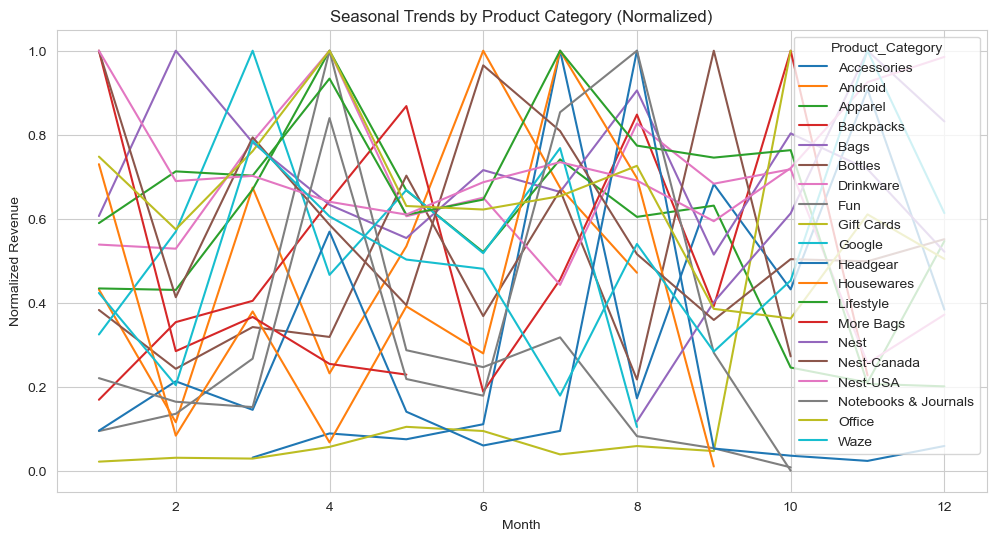

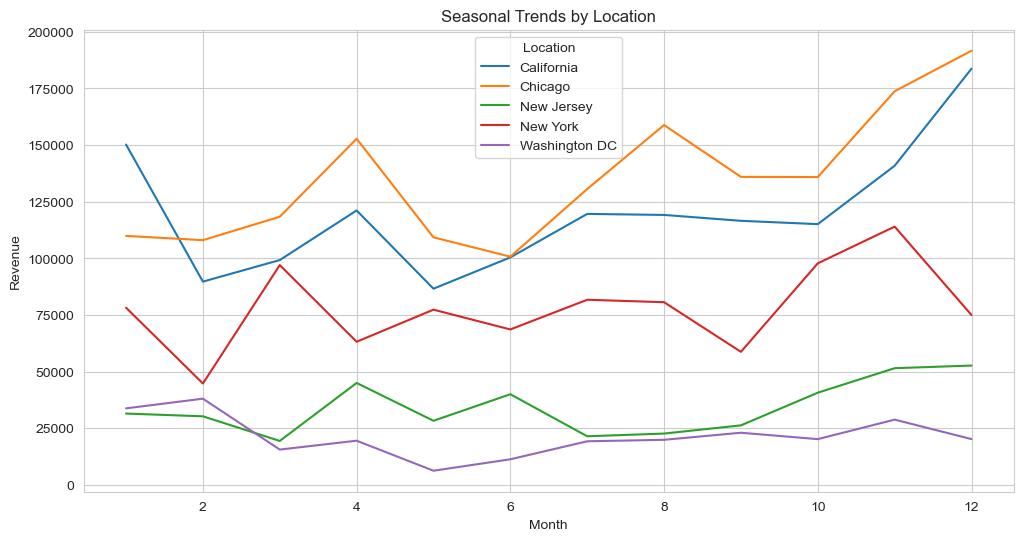


Seasonal preparation strategies:
1. Adjust inventory levels based on category-specific seasonal patterns
2. Plan marketing campaigns to align with natural demand surges
3. Develop off-season promotions for categories with strong seasonality
4. Tailor regional strategies based on location-specific patterns
5. Cross-train staff to handle category-specific peak periods


In [26]:
# Seasonal analysis by category
category_seasonal = merged_data.pivot_table(
    index='Month',
    columns='Product_Category',
    values='Revenue',
    aggfunc='sum'
)

# Normalize by max value for each category to see patterns
category_seasonal_norm = category_seasonal / category_seasonal.max()

# Plot
category_seasonal_norm.plot(figsize=(12, 6))
plt.title('Seasonal Trends by Product Category (Normalized)')
plt.ylabel('Normalized Revenue')
plt.show()

# By location
location_seasonal = merged_data.pivot_table(
    index='Month',
    columns='Location',
    values='Revenue',
    aggfunc='sum'
)
location_seasonal.plot(figsize=(12, 6))
plt.title('Seasonal Trends by Location')
plt.ylabel('Revenue')
plt.show()

# Strategies
print("\nSeasonal preparation strategies:")
print("1. Adjust inventory levels based on category-specific seasonal patterns")
print("2. Plan marketing campaigns to align with natural demand surges")
print("3. Develop off-season promotions for categories with strong seasonality")
print("4. Tailor regional strategies based on location-specific patterns")
print("5. Cross-train staff to handle category-specific peak periods")

### 20) Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?

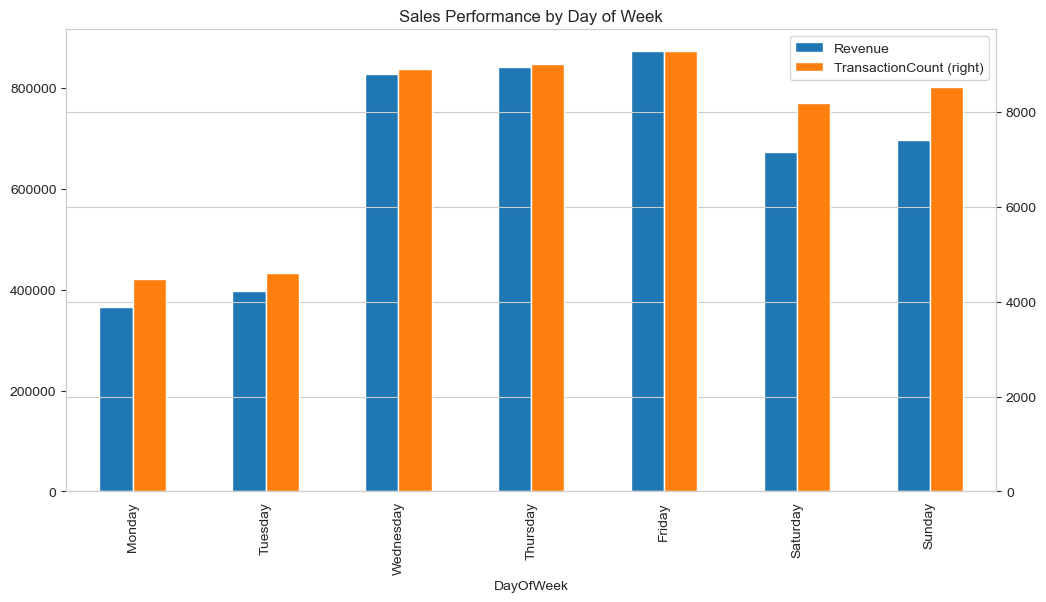

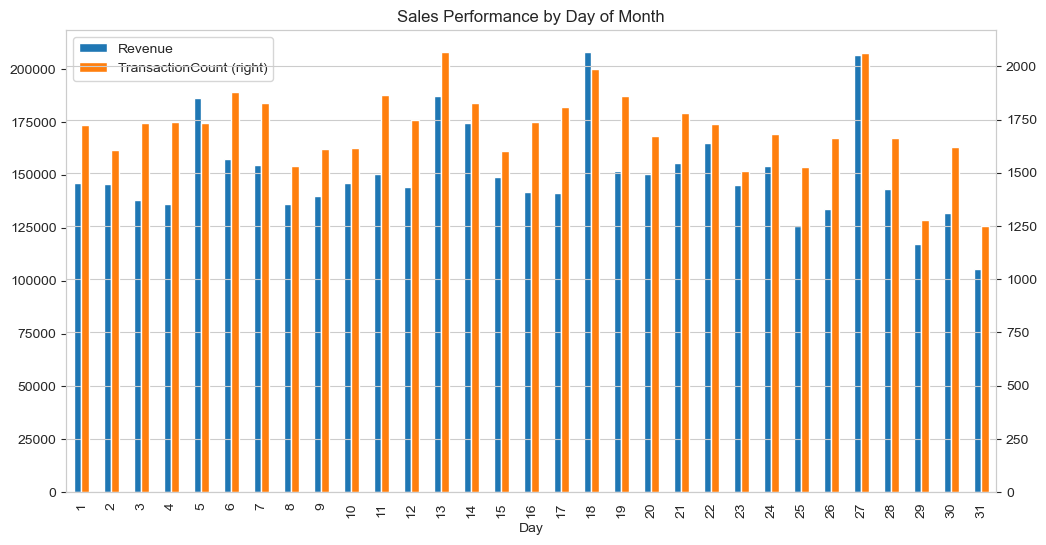


Daily sales strategies:
1. For slow days: Run flash sales or limited-time offers
2. For peak days: Ensure adequate staffing and inventory availability
3. Time marketing communications to arrive before typical purchase days
4. Analyze whether slow days represent opportunities or natural low points
5. Test different promotional strategies on various days to find optimal mix


In [27]:
# Analyze by day of week
day_of_week = merged_data.groupby('DayOfWeek').agg({
    'Revenue': 'sum',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'TransactionCount'})
day_of_week = day_of_week.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plot
day_of_week.plot(kind='bar', secondary_y='TransactionCount', figsize=(12, 6))
plt.title('Sales Performance by Day of Week')
plt.show()

# Analyze by day of month
day_of_month = merged_data.groupby('Day').agg({
    'Revenue': 'sum',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'TransactionCount'})

day_of_month.plot(kind='bar', secondary_y='TransactionCount', figsize=(12, 6))
plt.title('Sales Performance by Day of Month')
plt.show()

# Strategies
print("\nDaily sales strategies:")
print("1. For slow days: Run flash sales or limited-time offers")
print("2. For peak days: Ensure adequate staffing and inventory availability")
print("3. Time marketing communications to arrive before typical purchase days")
print("4. Analyze whether slow days represent opportunities or natural low points")
print("5. Test different promotional strategies on various days to find optimal mix")